# Requirements to collpase requirements tables Note + Making Concordances Concord - Tony Gui

In [1]:
import pandas as pd
from IPython.display import clear_output
import numpy as np
from statsmodels.tsa.api import VAR
import os
from data_cleaning_functions import requirements_clean, concordance_PCE_clean, \
    find_intermediate_industries, concordance_PCQ_clean, get_sales_from_make_matrix, clean_make_matrix, \
    get_demand_shock_from_shaipro_output, get_expenditure_weights_from_shapiro_outputs,plot_shapiro_graph_from_shapiro_ouput,clean_bea_PQE_table, get_final_demand_from_use_table,\
        clean_bea_peq_table

from pathlib import Path
import matplotlib.pyplot as plt

script_dir = str(Path().resolve().parent)
file_path = os.path.join(script_dir) + "/" 
shapiro_file =  file_path + "Shapiro"
raw_data_path = file_path + "raw_bea_data" 

/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# For Messing with Concordance Leave as is includes PEQ and PCE and no Fake Data

In [2]:
concordance = pd.read_excel(os.path.join(raw_data_path, "PCEBridge_2017_DET.xlsx"), sheet_name="2017")
PEQ_concordance = pd.read_excel(os.path.join(raw_data_path, "PEQBridge_2017_DET.xlsx"), sheet_name="2017")

# exported full concordance from the no_PEQ notebook
# no_peq_concordance = pd.read_csv(
#     os.path.join("/Users/tonygui/Desktop/Fake_concordance.csv")
# )

pce = concordance_PCE_clean(concordance).copy()
peq = concordance_PCE_clean(PEQ_concordance).copy()

def normalize_bridge(df):
    out = df.copy()
    for col in ["PCE Bridge Products", "PCE Bridge Industries"]:
        out[col] = out[col].astype(str).str.strip().str.lower()
        out.loc[out[col].isin(["nan", "none"]), col] = np.nan
    out = out.dropna(subset=["PCE Bridge Products", "PCE Bridge Industries"])
    return out


pce = normalize_bridge(pce)
peq = normalize_bridge(peq)
# no_peq_concordance = normalize_bridge(no_peq_concordance)

# keep all PCE rows; only use PEQ for industries not already covered by PCE
pce_industries = set(pce["PCE Bridge Industries"])
peq_only = peq.loc[~peq["PCE Bridge Industries"].isin(pce_industries)].copy()

master_concordance = pd.concat([pce, peq_only], ignore_index=True)
master_concordance = master_concordance.drop_duplicates(
    subset=["PCE Bridge Industries", "PCE Bridge Products"]
).reset_index(drop=True)

# harmonize naming before checking what is still uncovered
for df in [master_concordance]:
    df["PCE Bridge Industries"] = df["PCE Bridge Industries"].replace(
        "pump and pumping equipment manufacturing",
        "measuring, dispensing, and other pumping equipment manufacturing"
    )

# use the exact same fake mappings from no_PEQ,
# but only for industries still uncovered after PCE + PEQ
# covered_industries = set(master_concordance["PCE Bridge Industries"])

# fake_fill_only = (
#     no_peq_concordance.loc[
#         ~no_peq_concordance["PCE Bridge Industries"].isin(covered_industries),
#         ["PCE Bridge Products", "PCE Bridge Industries"]
#     ]
#     .drop_duplicates(subset=["PCE Bridge Industries"], keep="first")
#     .reset_index(drop=True)
# )

# master_concordance = pd.concat(
#     [master_concordance, fake_fill_only],
#     ignore_index=True
# )

# master_concordance = master_concordance.drop_duplicates(
#     subset=["PCE Bridge Industries", "PCE Bridge Products"]
# ).reset_index(drop=True)

concordance = master_concordance
# concordance


# 1. Load in Requirements Matrix 

In [3]:
requirements = pd.read_excel(os.path.join(raw_data_path, 'IxI_TR_2017_PRO_Det.xlsx'), sheet_name='2017')
requirements = requirements_clean(requirements)
requirements

2,oilseed farming,grain farming,vegetable and melon farming,fruit and tree nut farming,"greenhouse, nursery, and floriculture production",other crop farming,dairy cattle and milk production,"beef cattle ranching and farming, including feedlots and dual-purpose ranching and farming",poultry and egg production,"animal production, except cattle and poultry and eggs",...,federal general government (nondefense),postal service,federal electric utilities,other federal government enterprises,state and local government (educational services),state and local government (hospitals and health services),state and local government (other services),state and local government passenger transit,state and local government electric utilities,other state and local government enterprises
nan,,,,,,,,,,,,,,,,,,,,,
oilseed farming,1.279779,0.014409,0.004929,0.001729,0.001137,0.00316,0.023745,0.01215,0.048375,0.006966,...,-0.000636,0.000089,0.000451,0.002027,0.000422,0.0018,0.000539,0.002588,0.000153,0.000357
grain farming,0.002576,1.160693,0.005144,0.004288,0.002814,0.027177,0.103283,0.116055,0.147067,0.023998,...,0.0003,0.000189,0.00128,0.007513,0.001212,0.004625,0.001335,0.006901,0.000319,0.000772
vegetable and melon farming,0.000224,0.000785,1.037335,0.000679,0.000341,0.000616,0.000247,0.000177,0.000243,0.000105,...,0.000006,0.000004,0.00019,0.000907,0.00014,0.000308,0.000098,0.000019,0.000004,0.000009
fruit and tree nut farming,0.000245,0.000826,0.000647,1.026228,0.000361,0.000646,0.000507,0.000257,0.000495,0.000154,...,0.000032,0.000022,0.000933,0.003551,0.000496,0.002885,0.000562,0.000058,0.000017,0.000033
"greenhouse, nursery, and floriculture production",0.000769,0.002365,0.001809,0.001517,1.152284,0.002257,0.000938,0.000594,0.000857,0.000322,...,0.000109,0.000067,0.000186,0.000286,0.000117,0.000714,0.00162,0.001763,0.000117,0.00025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
state and local government (hospitals and health services),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000051,0.0,0.0,0.000001,0.0,1.000321,0.0,0.0,0.0,0.0
state and local government (other services),0.003345,0.010249,0.007965,0.007278,0.004364,0.008178,0.004048,0.002967,0.003636,0.001896,...,0.001066,0.001097,0.001879,0.002528,0.000768,0.00152,1.003711,0.003982,0.002619,0.002899
state and local government passenger transit,0.00012,0.000219,0.000136,0.000084,0.00011,0.000162,0.000203,0.000135,0.000233,0.000067,...,0.000143,0.000069,0.000191,0.000718,0.002467,0.000231,0.000541,1.008448,0.000119,0.000197


# 2. Calculate Delta

In [4]:
requirements = requirements.T
requirements = requirements.fillna(0)
requirements_to_delta = np.asarray(requirements, dtype=np.float64)
delta = np.identity(len(requirements_to_delta)) - np.linalg.inv(requirements_to_delta)
delta

array([[2.18230496e-01, 4.40683470e-04, 1.58573724e-04, ...,
        1.26996423e-06, 5.56401465e-04, 1.29145939e-02],
       [8.69983432e-03, 1.34678082e-01, 6.32280326e-04, ...,
        2.99931551e-06, 4.89773260e-04, 2.80987809e-02],
       [2.87985181e-03, 1.56677551e-03, 3.59778733e-02, ...,
        5.46202911e-07, 2.35506830e-03, 2.87196685e-02],
       ...,
       [7.30710756e-08, 8.52456228e-08, 5.12391827e-08, ...,
        8.09158658e-03, 8.42910778e-04, 2.33319882e-03],
       [1.34253220e-10, 3.09135792e-08, 2.01528360e-08, ...,
        9.69786639e-06, 5.65700212e-04, 1.13693450e-02],
       [7.91307821e-09, 4.43092759e-08, 3.36841533e-08, ...,
        1.53823502e-05, 4.58525716e-04, 7.31267212e-03]], shape=(402, 402))

# 2 (Making Concordances Concord) Adding Scrap, Used and secondhand goods and ROW adjustments to Delta

In [5]:
"""These 4 industries are found in the concordance table but not in the Reqirements table so I am 
adding them manually with row and column inputs of zero"""
concordance_but_not_requirments = ["Scrap", "Used and secondhand goods", "Rest of the world adjustment", "noncomparable imports"] 
delta = pd.DataFrame(delta, index=requirements.index, columns=requirements.columns)
delta = delta.reindex(index=requirements.index.append(pd.Index(concordance_but_not_requirments)).str.lower() , columns=requirements.columns.append(pd.Index(concordance_but_not_requirments)).str.lower() , fill_value=0)
delta

,oilseed farming,grain farming,vegetable and melon farming,fruit and tree nut farming,"greenhouse, nursery, and floriculture production",other crop farming,dairy cattle and milk production,"beef cattle ranching and farming, including feedlots and dual-purpose ranching and farming",poultry and egg production,"animal production, except cattle and poultry and eggs",...,state and local government (educational services),state and local government (hospitals and health services),state and local government (other services),state and local government passenger transit,state and local government electric utilities,other state and local government enterprises,scrap,used and secondhand goods,rest of the world adjustment,noncomparable imports
oilseed farming,2.182305e-01,4.406835e-04,1.585737e-04,1.608751e-04,1.585959e-04,4.303772e-03,3.059061e-04,1.258588e-03,5.658938e-04,6.267435e-04,...,0.000001,2.648539e-09,0.001996,1.269964e-06,0.000556,0.012915,0.0,0.0,0.0,0.0
grain farming,8.699834e-03,1.346781e-01,6.322803e-04,6.412868e-04,6.323431e-04,8.904588e-03,1.219444e-03,5.363358e-03,1.138804e-03,3.121992e-03,...,0.000004,6.914341e-09,0.007465,2.999316e-06,0.000490,0.028099,0.0,0.0,0.0,0.0
vegetable and melon farming,2.879852e-03,1.566776e-03,3.597787e-02,5.720080e-04,5.639853e-04,4.426647e-04,1.087635e-03,2.470001e-03,1.015753e-03,1.101832e-03,...,0.000002,1.644074e-08,0.006705,5.462029e-07,0.002355,0.028720,0.0,0.0,0.0,0.0
fruit and tree nut farming,7.340969e-04,1.550789e-03,6.284265e-04,2.553083e-02,5.581646e-04,4.351929e-04,1.076470e-03,3.931517e-03,1.005375e-03,1.872118e-03,...,0.000001,-6.199510e-09,0.006478,1.658714e-07,0.001537,0.020232,0.0,0.0,0.0,0.0
"greenhouse, nursery, and floriculture production",3.650259e-04,7.710037e-04,2.774939e-04,2.815021e-04,1.316849e-01,2.236586e-04,5.352380e-04,1.699724e-03,4.998527e-04,7.544837e-04,...,0.000001,-4.228297e-08,0.003166,2.865100e-07,0.000520,0.004565,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
other state and local government enterprises,7.913078e-09,4.430928e-08,3.368415e-08,5.390985e-08,1.475397e-08,-2.887312e-09,4.936176e-09,3.347282e-08,3.480128e-09,5.309115e-08,...,0.000009,-8.258717e-09,0.001245,1.538235e-05,0.000459,0.007313,0.0,0.0,0.0,0.0
scrap,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0.0
used and secondhand goods,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0.0
rest of the world adjustment,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0.0


# 2.5b Making Negative Values in Delta Zero

In [6]:
negative_count = (delta < 0).sum().sum()
percent_of_negatives_before = negative_count/402**2
delta[delta < 0] = 0
negative_count_new = (delta < 0).sum().sum()
percent_of_negatives_after = negative_count_new/402**2

# 2.5b Force negatives to be zero but adjust row sums to be same as before

In [7]:
# V = delta.sum(axis=0)
# P = delta[delta > 0].sum()
# delta.loc['norm'] = V/P
# last_values = delta.iloc[-1]
# delta[delta < 0] = 0
# delta = delta.iloc[:-1].div(last_values)
# delta

# Dealting with Intermediate Industries - Making Concordances Concord Section 3.3.1. - Operationalizing Industries without Products

# Step 1. Making Concordances Concord

In [8]:
use_table = pd.read_excel(os.path.join(raw_data_path, "Use_SUT_Framework_2017_DET.xlsx"), sheet_name="2017")

# Returns all industries with zero PCE 
intermediate_industries = find_intermediate_industries(use_table)
intermediate_industries = intermediate_industries.iloc[:, [0]]
intermediate_industries = intermediate_industries.sort_values(by="Industry")
intermediate_industries

,Industry
106,air and gas compressor manufacturing
163,aircraft engine and engine parts manufacturing
67,"all other forging, stamping, and sintering"
344,"all other miscellaneous professional, scientif..."
291,all other retail
...,...
81,valve and fittings other than plumbing
42,"veneer, plywood, and engineered wood product m..."
281,wholesale electronic markets and agents and br...
145,wiring device manufacturing


In [9]:


# clean comparison keys
pce_products = (
    master_concordance["PCE Bridge Industries"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
)

intermediate_key = (
    intermediate_industries["Industry"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# rows to remove
mask_remove = intermediate_key.isin(pce_products)

print("Rows before:", len(intermediate_industries))
print("Rows removed:", mask_remove.sum())

# keep only rows NOT in PCE Bridge Products
intermediate_industries_clean = intermediate_industries.loc[~mask_remove].copy()

intermediate_industries = intermediate_industries_clean

Rows before: 143
Rows removed: 41


# Steps 2 - 5. Making Concordances Concord - Loop over Intermediate Industries and Remove

In [10]:
# For the Loop 
big_lambda = np.eye(len(delta)) # create a big_lambda identity matrix that will become out final output
big_lambda = pd.DataFrame(big_lambda)
big_lambda = big_lambda.set_index(delta.index)
big_lambda.columns = delta.index
delta_industries = delta.index # save all the requirment table industries outside the loop 
removed = [] # stores all removed industries through the loop 

i = 0
for row in intermediate_industries.iloc[::-1].itertuples(): # looping backwards
    i += 1 
    current = row.Industry # industry we are currently removing
    # Create identity matrix for current loop iteration
    phi_i = np.eye(len(delta) - (i - 1))
    phi_i = pd.DataFrame(phi_i)
    phi_i = phi_i.set_index(delta_industries)
    phi_i.columns = delta_industries

    current_intermediate_use_table = delta.copy() # use a new intermediates use matrix each time we do this
    # Remove all the industries we've previously removed in earlier loop iterations 
    current_intermediate_use_table.drop(columns=removed, inplace=True)
    current_intermediate_use_table = current_intermediate_use_table.loc[[current]] # the row of the intermediates use table associated with the current industry  
    current_intermediate_use_table.drop(columns=[current], inplace=True) # drop the column associated with the current industry so we dont include it in our sum
    current_intermediate_use_table = current_intermediate_use_table.astype(float)
    current_industry_sum = current_intermediate_use_table.loc[current].sum() # find sum of row

    # just making sure that we aren't dividing by zero 
    if current_industry_sum != 0:
        current_intermediate_use_table = current_intermediate_use_table.astype(float)
        current_intermediate_use_table.loc[current] = current_intermediate_use_table.loc[current] / current_industry_sum


    current_intermediate_use_table = current_intermediate_use_table[sorted(current_intermediate_use_table.columns)] # sort the normazlied row alphabetically

    # remove the current industry from intermediate list
    intermediate_industries = intermediate_industries[intermediate_industries['Industry'] != current]
    # drop the current industry column from phi_i and industry indexing
    phi_i = phi_i.drop(columns=current)
    delta_industries = delta_industries.drop(current) 
    
    removed.append(current)

    # Update phi_i with the current industry sale shares
    phi_i.loc[current_intermediate_use_table.index] = current_intermediate_use_table.loc[current_intermediate_use_table.index].astype(np.float64).values
    big_lambda_old = big_lambda
    big_lambda = big_lambda @ phi_i

# Step 6. Making Concordances Concord - Converting IO matrix from sales shares to dollars

In [11]:
make_matrix = pd.read_excel(os.path.join(raw_data_path, "Supply_2017_DET.xlsx"), sheet_name="2017")
sales_vector = get_sales_from_make_matrix(make_matrix) # returns the sales for each industry

# these industries are not in the make matrix so i will add them manually with zero entries to preserve df sizes
industries_not_in_make_matrix = ["state and local government passenger transit", "state and local government electric utilities", \
                      "secondary smelting and alloying of aluminum", "federal electric utilities"]
not_in_make_matrix = pd.DataFrame({'Industries': industries_not_in_make_matrix, 'Sales': [0,0,0,0]})
sales_vector = pd.concat([sales_vector, not_in_make_matrix], ignore_index=True)
sales_vector.set_index('Industries', inplace=True)

# repeat the sales vector n times to make a sales matrix
sales_repeated = pd.DataFrame({f'{i}': sales_vector['Sales'].values for i in range(1, len(delta))})
sales_repeated.set_index(sales_vector.index, inplace=True)
sales_matrix = pd.concat([sales_vector, sales_repeated], axis=1)
sales_matrix.columns = delta.columns

# Y is IO matrix in dollars 
Y = delta * sales_matrix 

# Step 7. Making Concordances Concord - Value Added for the Economy

In [12]:
sum_Y = Y.sum(axis=1).to_frame()
sum_Y.columns = ['Sales']
VA_pre_transformation = (sales_vector - sum_Y).sum()

# Step 8. Making Concordances Concord - IO Matrix in USD

In [13]:
# new IO matrix in USD 
Y_tilde = big_lambda.T @ Y @ big_lambda
sales_tilde = big_lambda.T @ sales_vector

# Verifing that economy wide value added is identical to the pre-transformation level
sum_Y_tilde = Y_tilde.sum(axis=1).to_frame()
sum_Y_tilde.columns = ['Sales']
VA_post_transformation = (sales_tilde - sum_Y_tilde).sum()
# VA_post_transformation

In [14]:
# """Pre transformation and post transformation are not the same"""
# differnece = VA_post_transformation - VA_pre_transformation
# differnece

# Step 9. Making Concordances Concord - Calculating New Delta

In [15]:
recip_sales = 1/sales_tilde
sales_tilde_repeated = pd.DataFrame({f'{i}': recip_sales['Sales'].values for i in range(1, len(delta))})
sales_tilde_repeated.set_index(recip_sales.index, inplace=True)
sales_tilde_matrix = pd.concat([recip_sales, sales_tilde_repeated], axis=1)
sales_tilde_matrix.columns = delta.columns

delta_tilde = Y_tilde * sales_tilde_matrix
delta = delta_tilde
# delta

# End of Making Concordances Concord - Back to Requirements to Collapse Requirements Table

# 3. Merge Concordance with Delta

In [16]:
concordance = pd.read_excel(os.path.join(raw_data_path, "PCEBridge_2017_DET.xlsx"), sheet_name="2017")
PEQ_concordance = pd.read_excel(os.path.join(raw_data_path, "PEQBridge_2017_DET.xlsx"), sheet_name="2017")


pce = concordance_PCE_clean(concordance).copy()
peq = concordance_PCE_clean(PEQ_concordance).copy()

# keep all PCE rows; only use PEQ for industries not already covered by PCE
pce_industries = set(pce["PCE Bridge Industries"])
peq_only = peq.loc[~peq["PCE Bridge Industries"].isin(pce_industries)].copy()

master_concordance = pd.concat([pce, peq_only], ignore_index=True)
master_concordance = master_concordance.drop_duplicates(
    subset=["PCE Bridge Industries", "PCE Bridge Products"]
).reset_index(drop=True)

master_concordance["PCE Bridge Industries"] = master_concordance["PCE Bridge Industries"].replace(
    "pump and pumping equipment manufacturing",
    "measuring, dispensing, and other pumping equipment manufacturing"
)

concordance = master_concordance


concordance

concordance = pd.read_excel(os.path.join(raw_data_path, "PCEBridge_2017_DET.xlsx"), sheet_name="2017")
concordance = concordance_PCE_clean(concordance)
# concordance


In [17]:
"""'federal electric utilities', 'secondary smelting and alloying of aluminum', 'state and local government electric utilities', 'state and local government passenger transit' 
are not an intermediate industry nor do they exist in the PCE concordance so we will simply drop"""
industries_in_requirments = set(delta.columns)
indsutries_in_concordance = set(concordance["PCE Bridge Industries"])
industires_not_in_concordance = industries_in_requirments - indsutries_in_concordance
delta = delta.drop(index=industires_not_in_concordance, columns=industires_not_in_concordance, errors='ignore')
delta

,abrasive product manufacturing,accommodation,"accounting, tax preparation, bookkeeping, and payroll services",adhesive manufacturing,"advertising, public relations, and related services","air conditioning, refrigeration, and warm air heating equipment manufacturing",air transportation,aircraft manufacturing,all other chemical product and preparation manufacturing,all other converted paper product manufacturing,...,veterinary services,warehousing and storage,waste management and remediation services,"watch, clock, and other measuring and controlling device manufacturing",water transportation,"water, sewage and other systems",wet corn milling,wineries,wired telecommunications carriers,wireless telecommunications carriers (except satellite)
grain farming,0.000188,0.001068,0.003304,0.001139,0.001269,0.000916,0.005387,0.000979,0.001456,0.000308,...,0.000258,0.002060,0.002073,0.000876,0.012321,0.003917,0.001397,0.000214,0.003575,0.002988
vegetable and melon farming,0.000230,0.001665,0.005193,0.000947,0.004023,0.000883,0.004704,0.002603,0.001554,0.000364,...,0.000412,0.006071,0.003217,0.001067,0.001708,0.001545,0.000730,0.000360,0.004731,0.005343
fruit and tree nut farming,0.000216,0.001177,0.006459,0.001484,0.005056,0.000993,0.002932,0.000240,0.001511,0.000303,...,0.000347,0.007198,0.001654,0.000984,0.000996,0.001106,0.000490,0.000321,0.002847,0.003013
"greenhouse, nursery, and floriculture production",0.000222,0.000852,0.004826,0.001474,0.004450,0.001074,0.003496,0.000444,0.001290,0.000336,...,0.000352,0.006858,0.002065,0.001054,0.003018,0.001102,0.001002,0.000300,0.003614,0.003436
other crop farming,0.000132,0.001117,0.005858,0.001023,0.007926,0.000751,0.003396,0.000410,0.001443,0.000317,...,0.000244,0.010158,0.001804,0.000940,0.001492,0.001249,0.000671,0.000311,0.003201,0.003217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
other state and local government enterprises,0.000442,0.001305,0.005750,0.002547,0.002866,0.000673,0.001644,0.000672,0.002358,0.000522,...,0.000318,0.001886,0.008819,0.001312,0.001111,0.001918,0.002578,0.002102,0.009654,0.001872
scrap,0.000192,0.001195,0.003760,0.000820,0.002915,0.000901,0.002686,0.000959,0.001636,0.000363,...,0.000430,0.004705,0.003865,0.000799,0.000623,0.000715,0.000633,0.000300,0.008985,0.006173
used and secondhand goods,0.000171,0.001749,0.004083,0.000885,0.003382,0.000962,0.004717,0.004230,0.001873,0.000453,...,0.000635,0.006012,0.005504,0.001159,0.000838,0.000819,0.000639,0.000377,0.006216,0.008773
rest of the world adjustment,0.000380,0.000522,0.002121,0.001875,0.002247,0.005193,0.002434,0.000835,0.002156,0.000346,...,0.000761,0.002356,0.001929,0.001539,0.001094,0.001468,0.001046,0.000157,0.002343,0.003451


In [18]:
in_num_products = concordance['PCE Bridge Industries'].value_counts()

delta_product_columns = pd.DataFrame(index=delta.index, columns=concordance['PCE Bridge Products'])

for column in delta_product_columns: 
    industry = concordance.loc[concordance['PCE Bridge Products'] == column, 'PCE Bridge Industries'].values
    delta_product_columns[column] = delta[industry] / in_num_products[industry]

delta_product_cr = pd.DataFrame(columns=delta_product_columns.columns)
lst_for_industry = []
for row in delta_product_columns.index:
    final_value = delta_product_columns.loc[row] / in_num_products[row]
    products = concordance[concordance['PCE Bridge Industries'] == row]['PCE Bridge Products'].tolist()
    for product in products: 
        lst_for_industry.append(row)
        final_value_row = pd.DataFrame(final_value).T
        final_value_row.index = [product]
        
        delta_product_cr = pd.concat([delta_product_cr, final_value_row])

industry = pd.DataFrame(lst_for_industry, columns=['industry'])
industry.index = delta_product_cr.index
delta_product_cr = pd.concat([delta_product_cr, industry], axis = 1)
delta_product_cr

,new domestic autos,new domestic autos,new foreign autos,new light trucks,used autos,used autos,used light trucks,used light trucks,tires,tires,...,final consumption expenditures of nonprofit institutions serving households,final consumption expenditures of nonprofit institutions serving households,final consumption expenditures of nonprofit institutions serving households,final consumption expenditures of nonprofit institutions serving households,final consumption expenditures of nonprofit institutions serving households,final consumption expenditures of nonprofit institutions serving households,final consumption expenditures of nonprofit institutions serving households,tenant-occupied stationary homes,"tenant-occupied, including landlord durables",industry
cereals,0.000007,0.000019,0.000007,0.000012,0.00006,0.000011,0.00006,0.000011,0.00052,0.000011,...,0.000083,0.000009,0.000004,0.000018,0.000011,0.000013,0.000038,0.000012,0.000012,grain farming
processed fruits and vegetables,0.000007,0.000019,0.000007,0.000012,0.00006,0.000011,0.00006,0.000011,0.00052,0.000011,...,0.000083,0.000009,0.000004,0.000018,0.000011,0.000013,0.000038,0.000012,0.000012,grain farming
pets and related products,0.000007,0.000019,0.000007,0.000012,0.00006,0.000011,0.00006,0.000011,0.00052,0.000011,...,0.000083,0.000009,0.000004,0.000018,0.000011,0.000013,0.000038,0.000012,0.000012,grain farming
food furnished to employees (including military),0.000007,0.000019,0.000007,0.000012,0.00006,0.000011,0.00006,0.000011,0.00052,0.000011,...,0.000083,0.000009,0.000004,0.000018,0.000011,0.000013,0.000038,0.000012,0.000012,grain farming
vegetables (fresh),0.000007,0.000024,0.000007,0.000018,0.000056,0.00001,0.000056,0.00001,0.00018,0.00001,...,0.000071,0.000018,0.000024,0.000025,0.000003,0.000013,0.000072,0.000016,0.000016,vegetable and melon farming
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
less: expenditures in the united states by nonresidents,0.000009,0.00003,0.000009,0.00008,0.0001,0.000016,0.0001,0.000016,0.000378,0.000016,...,0.000046,0.000007,0.000022,0.00002,0.000002,0.000022,0.000193,0.000017,0.000017,rest of the world adjustment
government employees' expenditures abroad,0.000006,0.00002,0.000006,0.000045,0.000075,0.000011,0.000075,0.000011,0.000239,0.000011,...,0.000031,0.000003,0.000011,0.000015,0.000001,0.000012,0.000175,0.00001,0.00001,noncomparable imports
private employees' expenditures abroad,0.000006,0.00002,0.000006,0.000045,0.000075,0.000011,0.000075,0.000011,0.000239,0.000011,...,0.000031,0.000003,0.000011,0.000015,0.000001,0.000012,0.000175,0.00001,0.00001,noncomparable imports
u.s. travel outside the united states,0.000006,0.00002,0.000006,0.000045,0.000075,0.000011,0.000075,0.000011,0.000239,0.000011,...,0.000031,0.000003,0.000011,0.000015,0.000001,0.000012,0.000175,0.00001,0.00001,noncomparable imports


# 4. Collapse columns

In [19]:
delta_products = delta_product_cr.T.groupby(delta_product_cr.columns).sum().T
# delta_products

# 5. Make Matrix to Sales

In [20]:
make_matrix = pd.read_excel(os.path.join(raw_data_path, "Supply_2017_DET.xlsx"), sheet_name='2017')
sales = get_sales_from_make_matrix(make_matrix)
# sales

# 6. Merge concordance with sales 

In [21]:
product_sales = pd.merge(concordance, sales, left_on='PCE Bridge Industries', right_on='Industries')
product_sales = product_sales[["PCE Bridge Products", "Industries", 'Sales']]
# product_sales

# 7. Group sum of Sales for every Product

In [22]:
# calculates the number of product categories an Industry belongs to 
product_sales['In#Products'] = product_sales['Industries'].map(product_sales['Industries'].value_counts())
product_sales["Ratio_in_Product"] = product_sales['Sales'] / product_sales['In#Products'] 
product_sales['Sales_Sum'] = product_sales.groupby('PCE Bridge Products')['Ratio_in_Product'].transform('sum')
# product_sales

# 8. Sales Share 

In [23]:
product_sales['Sale Share'] = product_sales["Ratio_in_Product"] / product_sales["Sales_Sum"]
product_sales = product_sales.rename(columns={'Industries': 'industry'})
product_sales = product_sales.rename(columns={'PCE Bridge Products': 'product'})
# product_sales

# 9. Merge Sale shares and Delta

In [24]:
df_reset = delta_products.reset_index()
delta_products = df_reset.rename(columns={'index': 'product'})
delta_products_saleshare = delta_products.merge(product_sales, how = 'inner', on = ['industry', 'product'])
delta_products_saleshare = delta_products_saleshare.drop(columns=['Sales_Sum', "Ratio_in_Product", "In#Products", "Sales", "industry"])
delta_products_saleshare = delta_products_saleshare.set_index(delta_products_saleshare.columns[0])
# delta_products_saleshare

# 10. weightTimesDeltaValue + 11.

In [25]:
# Convert from Wide to Long
delta_final = delta_products_saleshare.reset_index().melt(id_vars=[delta_products_saleshare.index.name, "Sale Share"],
                                var_name="Column Products", value_name="value")

# Just Renaming and Reordering
delta_final = delta_final.rename(columns={delta_products_saleshare.index.name: "Row Products"})
delta_final = delta_final[['Row Products', 'Column Products', 'value', 'Sale Share']]
# Calculating weightTimesDeltaValue
delta_final["weightTimesDeltaValue"] = delta_final["value"] * delta_final["Sale Share"]

# Sum weightTimesDeltaValue grouping by Row Products AND Column Products
delta_final = delta_final.groupby(['Row Products', 'Column Products']).sum()
delta_final
# Convert Back to Wide Format 
delta_final = delta_final.pivot_table(values='weightTimesDeltaValue', index='Row Products', columns='Column Products')

# Removes Index and Column Names cuz it looks better. Both Index and Columns are simply Product Categories now
delta_final.columns.name = None 
delta_final.index.name = None 


labels_to_drop = ["government employees' expenditures abroad", "private employees' expenditures abroad","u.s. travel outside the united states","u.s. student expenditures"]
delta_final = delta_final.drop(index=labels_to_drop, columns=labels_to_drop, errors="ignore")

delta_final = delta_final.T

In [26]:
delta_final

,accessories and parts,air transportation,alcohol in purchased meals,all other professional medical services,"amusement parks, campgrounds, and related recreational services","audio discs, tapes, vinyl, and permanent digital downloads",audio equipment,auto leasing,bakery products,beef and veal,...,video and audio streaming and rental,"video discs, tapes, and permanent digital downloads",vocational rehabilitation services,watches,water supply and sewage maintenance,water transportation,window coverings,wine,women's and girls' clothing,workers' compensation
accessories and parts,0.116005,0.000354,0.001331,0.001512,0.00367,0.004066,0.007641,0.00763,0.003702,0.000529,...,0.004657,0.001385,0.011701,0.001242,0.002969,0.003259,0.003365,0.009876,0.00187,0.006625
air transportation,0.000389,0.000067,0.00019,0.000136,0.00028,0.000234,0.000302,0.000443,0.000269,0.000025,...,0.000488,0.000095,0.000185,0.000142,0.000139,0.000498,0.000138,0.000459,0.000131,0.000013
alcohol in purchased meals,0.002395,0.001053,0.001646,0.00252,0.00149,0.001719,0.001857,0.00184,0.001755,0.000161,...,0.004365,0.001486,0.003894,0.000851,0.001167,0.00114,0.000739,0.002314,0.000622,0.000463
all other professional medical services,0.000332,0.000033,0.000039,0.000174,0.000082,0.000073,0.000153,0.00006,0.00009,0.000014,...,0.000065,0.000038,0.000037,0.000035,0.000091,0.000098,0.000065,0.000229,0.000039,0.000026
"amusement parks, campgrounds, and related recreational services",0.001851,0.003352,0.00171,0.000447,0.001672,0.001491,0.001146,0.001615,0.001199,0.000382,...,0.001826,0.001868,0.000327,0.000324,0.00069,0.003823,0.000602,0.00196,0.000398,0.000408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
water transportation,0.000738,0.003924,0.000649,0.00015,0.000503,0.000404,0.000654,0.00026,0.000606,0.000169,...,0.000441,0.000195,0.000376,0.000135,0.000777,0.008463,0.000823,0.00102,0.000367,0.000061
window coverings,0.000414,0.00002,0.00011,0.000082,0.000147,0.000133,0.000224,0.00009,0.000224,0.000031,...,0.000097,0.000039,0.000542,0.000061,0.000158,0.000074,0.00047,0.000327,0.000076,0.000054
wine,0.000209,0.000158,0.001366,0.000112,0.000383,0.000105,0.00016,0.000095,0.000143,0.000025,...,0.000254,0.000057,0.000086,0.000084,0.000383,0.000092,0.000083,0.02331,0.00006,0.00001
women's and girls' clothing,0.001499,0.000041,0.000169,0.000173,0.000246,0.000281,0.000419,0.000126,0.000367,0.000088,...,0.000193,0.000093,0.000276,0.000101,0.000251,0.00014,0.00092,0.000712,0.000927,0.000199


# Fixing Products with no price, quantity or expendiuture data 

In [27]:
bea_prices = pd.read_excel(os.path.join(raw_data_path, 'Quarterly Price Index.xlsx'))
bea_prices = clean_bea_PQE_table(bea_prices, "Prices", long=True)
bea_prices = bea_prices[bea_prices['products'].isin(delta_final.index)]
bea_prices = bea_prices.drop_duplicates()
bea_prices['Prices'] = bea_prices['Prices'].replace('---', 0).astype(float)
bea_prices = bea_prices.fillna(0)

raw_peq_exp = pd.read_excel(
    os.path.join(raw_data_path, "PEQ Quarterly Expenditure.xlsx"),
    header=None
)

raw_peq_price = pd.read_excel(
    os.path.join(raw_data_path, "PEQ Quarterly Price.xlsx"),
    header=None
)

PEQ_expenditures = clean_bea_peq_table(raw_peq_exp, "Expenditures", long=True)
PEQ_Price = clean_bea_peq_table(raw_peq_price, "Prices", long=True)


bea_expenditures = pd.read_excel(os.path.join(raw_data_path, 'Quarterly Expenditure.xlsx'))
bea_expenditures = clean_bea_PQE_table(bea_expenditures, "Expenditures", long=True)
bea_expenditures = bea_expenditures[bea_expenditures['products'].isin(delta_final.index)]
bea_expenditures = bea_expenditures.drop_duplicates()
bea_expenditures['Expenditures'] = bea_expenditures['Expenditures'].replace('---', 0).astype(float)
bea_expenditures = bea_expenditures.fillna(0)


bea_quantities = pd.read_excel(os.path.join(raw_data_path, 'Quarterly Quantity Index.xlsx')) # read raw BEA quantities
bea_quantities = clean_bea_PQE_table(bea_quantities, "Quantities", long=True) 
bea_quantities = bea_quantities[bea_quantities['products'].isin(delta_final.index)] # drop products taht delta doesnt have
bea_quantities = bea_quantities.drop_duplicates()
bea_quantities['Quantities'] = bea_quantities['Quantities'].replace('---', 0).astype(float)
bea_quantities = bea_quantities.fillna(0)

"""Generate Quantity from Expenditure and Price"""

# -----------------------------
# PEQ quantity index from PEQ expenditures + PEQ prices
# fixed-base index with 2017 average = 100
# -----------------------------

peq_q = (
    PEQ_expenditures[["products", "date", "Expenditures"]]
    .merge(
        PEQ_Price[["products", "date", "Prices"]],
        on=["products", "date"],
        how="inner",
        validate="one_to_one"
    )
    .copy()
)

# make sure types are clean
peq_q["date"] = pd.to_datetime(peq_q["date"], errors="coerce")
peq_q["Expenditures"] = pd.to_numeric(peq_q["Expenditures"], errors="coerce")
peq_q["Prices"] = pd.to_numeric(peq_q["Prices"], errors="coerce")

# invalid prices -> missing
peq_q.loc[peq_q["Prices"] <= 0, "Prices"] = np.nan

# real quantity-like level before normalization
peq_q["real_unnormalized"] = peq_q["Expenditures"] / (peq_q["Prices"] / 100)

# 2017 average real level by product
base_2017 = (
    peq_q.loc[peq_q["date"].dt.year == 2017]
    .groupby("products", as_index=False)["real_unnormalized"]
    .mean()
    .rename(columns={"real_unnormalized": "base_2017_real"})
)

# merge base back
peq_q = peq_q.merge(base_2017, on="products", how="left", validate="many_to_one")

# quantity index, 2017 average = 100
peq_q["Quantities"] = 100 * peq_q["real_unnormalized"] / peq_q["base_2017_real"]

# clean infinities
peq_q["Quantities"] = peq_q["Quantities"].replace([np.inf, -np.inf], np.nan)

# final long table
PEQ_quantities = peq_q[["products", "date", "Quantities"]].copy()


peq_name_map = {
    "electrical equipment, n.e.c.": "electrical equipment, not elsewhere classified",
    "special industry machinery, n.e.c.": "special industry machinery, not elsewhere classified",
}

for df in [PEQ_expenditures, PEQ_Price, PEQ_quantities]:
    df["products"] = (
        df["products"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\d+$", "", regex=True)   # removes footnote markers like autos1
        .str.replace(r"\s+", " ", regex=True)
        .replace(peq_name_map)
    )

PEQ_expenditures = PEQ_expenditures[PEQ_expenditures['products'].isin(delta_final.index)]
PEQ_Price = PEQ_Price[PEQ_Price['products'].isin(delta_final.index)]
PEQ_quantities = PEQ_quantities[PEQ_quantities['products'].isin(delta_final.index)]

PEQ_expenditures["Expenditures"] = pd.to_numeric(PEQ_expenditures["Expenditures"], errors="coerce").fillna(0)
PEQ_Price["Prices"] = pd.to_numeric(PEQ_Price["Prices"], errors="coerce").fillna(0)

# stack PEQ onto BEA
bea_prices = (
    pd.concat([bea_prices, PEQ_Price], ignore_index=True)
    .drop_duplicates(subset=["products", "date"], keep="first")
    .reset_index(drop=True)
)

bea_expenditures = (
    pd.concat([bea_expenditures, PEQ_expenditures], ignore_index=True)
    .drop_duplicates(subset=["products", "date"], keep="first")
    .reset_index(drop=True)
)

bea_quantities = (
    pd.concat([bea_quantities, PEQ_quantities], ignore_index=True)
    .drop_duplicates(subset=["products", "date"], keep="first")
    .reset_index(drop=True)
)

for df in [bea_prices, bea_quantities, bea_expenditures, PEQ_Price, PEQ_expenditures, PEQ_quantities]:
    df["products"] = df["products"].astype(str).str.strip().str.lower()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")


bea_PQE_merged = pd.merge(left=bea_quantities, right=bea_prices, on=['products', 'date'], how='outer')
bea_PQE_merged = pd.merge(left=bea_PQE_merged, right=bea_expenditures, on=['products', 'date'], how='outer')

# dropping this because 2024-10 has no data yet 
bea_PQE_merged = bea_PQE_merged.dropna(subset=['Expenditures'])

dates = list(set(bea_expenditures["date"]) & set(bea_prices["date"]) & set(bea_quantities["date"]))
dates.sort() # get all BEA data quarterly dates

cols_to_check = ['Quantities', 'Prices', 'Expenditures']

# Create filtered DataFrame where at least one value is missing or zero
products_with_zero_somwhere = bea_PQE_merged[
    bea_PQE_merged[cols_to_check].isnull().any(axis=1) |
    (bea_PQE_merged[cols_to_check] == 0).any(axis=1)
]

all_bad_products_dict = {} # For every date products that dont have a value somewhere

for date in dates:
    bad_products_currnet = products_with_zero_somwhere[products_with_zero_somwhere['date'] == date]["products"]
    all_bad_products_dict[date] = bad_products_currnet.tolist()

""""For BEA I will set the entire BEA row to zero if any of the price, quantity or expenditure data is missing"""
zero_mask = (bea_PQE_merged[cols_to_check] == 0).any(axis=1)
# Set all three columns to 0 where the mask is True
bea_PQE_merged.loc[zero_mask, cols_to_check] = 0

bea_prices = bea_PQE_merged[["products", "date", "Prices"]]

/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/datacleaning/data_cleaning_functions.py:168: PerformanceWar

# 1. Calculate PCE Inflation

In [28]:
bea_expenditures_wide = bea_expenditures.pivot(index='products', columns='date', values='Expenditures')

to_zero = pd.concat(
    [
        peq_only["PCE Bridge Products"]
    ],
    ignore_index=True
).astype(str).str.strip().str.lower().drop_duplicates()


date_cols = [c for c in bea_expenditures_wide.columns if c != "products"]

bea_expenditures_wide.loc[
    bea_expenditures_wide.index.isin(to_zero),
    date_cols
] = 0

P = bea_prices.pivot(index='products', columns='date', values='Prices')

bea_expenditures_weights = bea_expenditures_wide.div(bea_expenditures_wide.sum(axis=0), axis=1)

computer software and accessories
personal computers/tablets and peripheral equipment


/var/folders/hx/h9ft_v812fs68lgk203tqsq80000gn/T/ipykernel_18103/1383937016.py:39: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


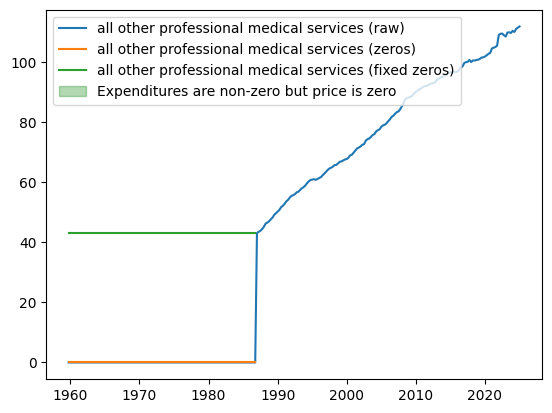

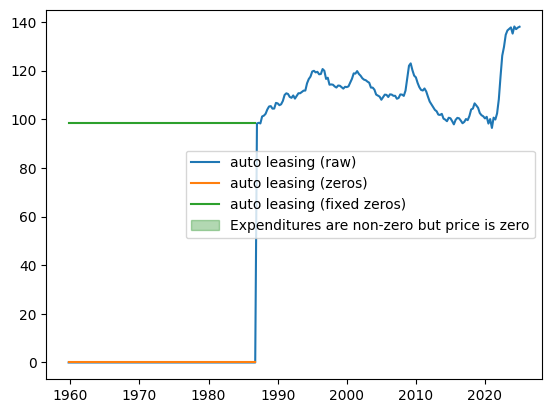

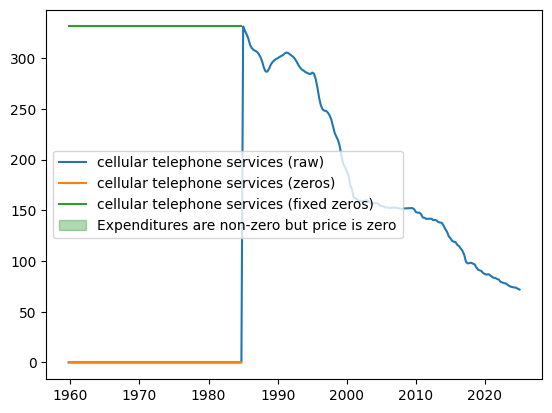

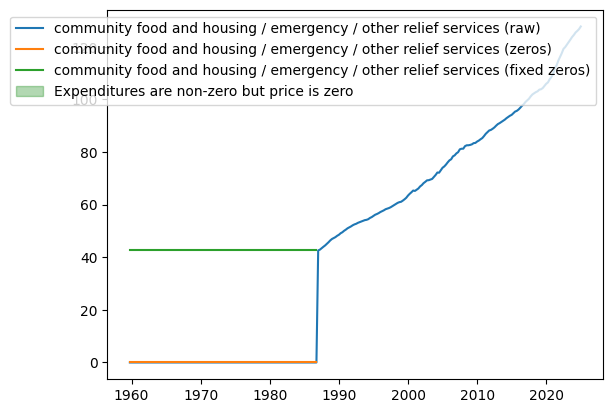

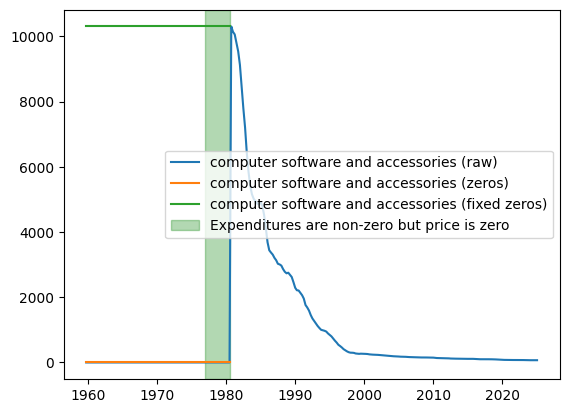

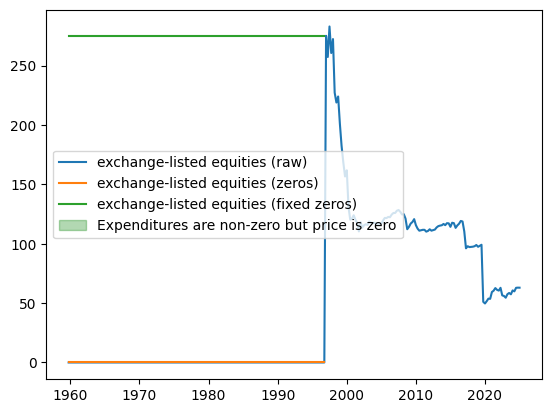

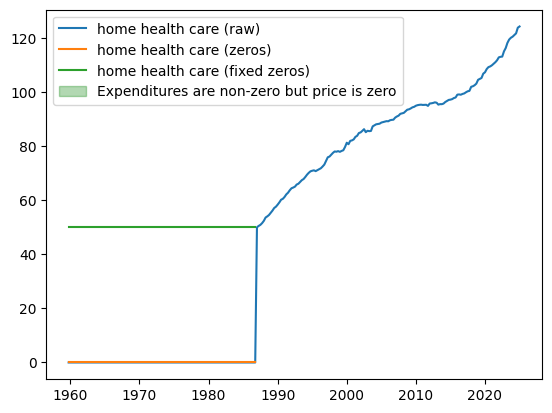

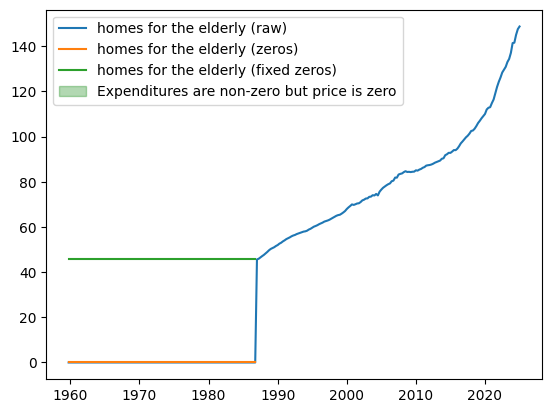

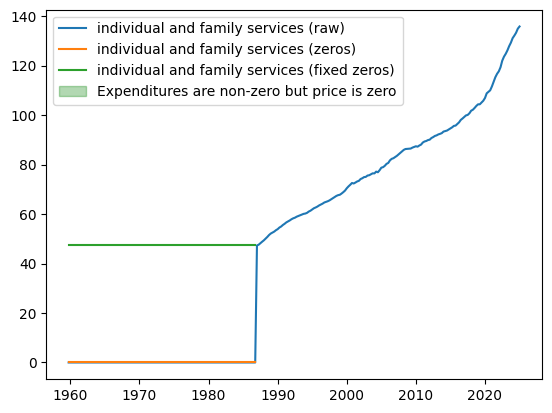

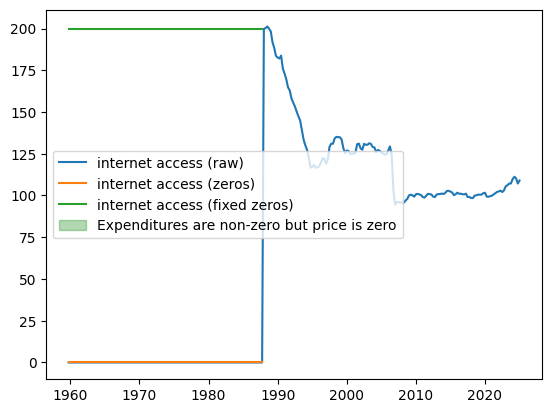

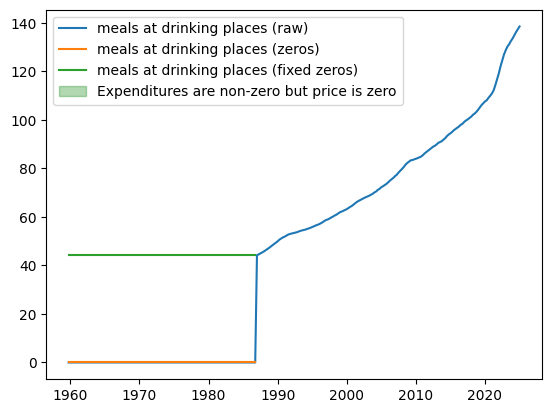

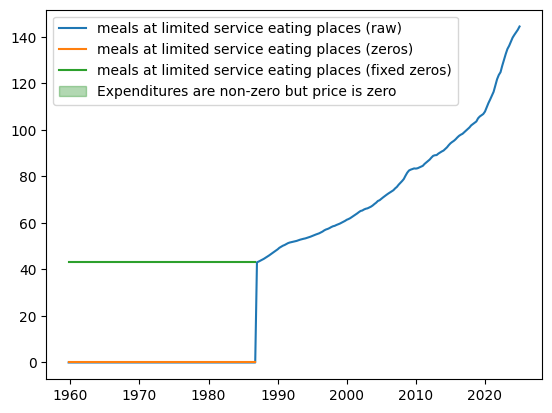

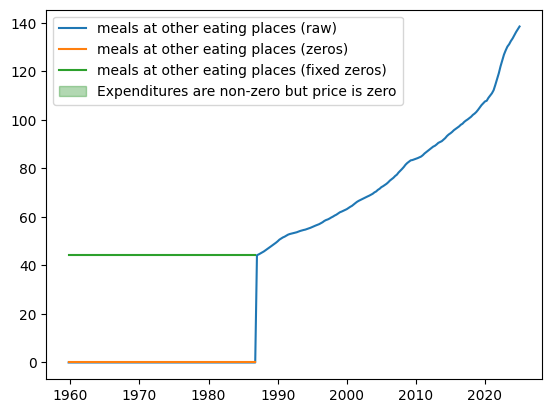

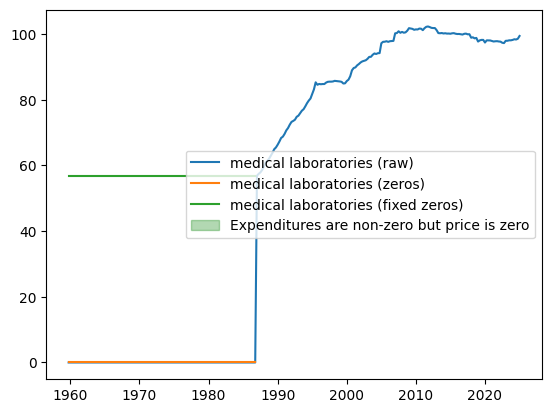

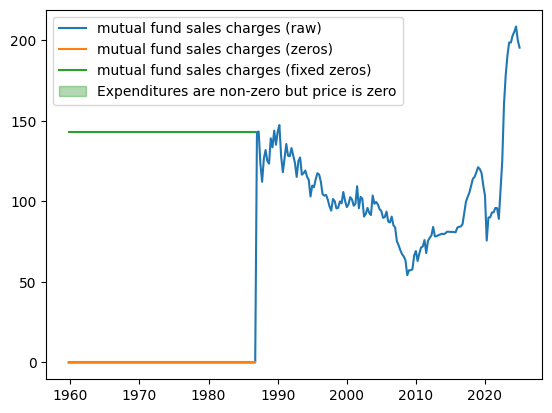

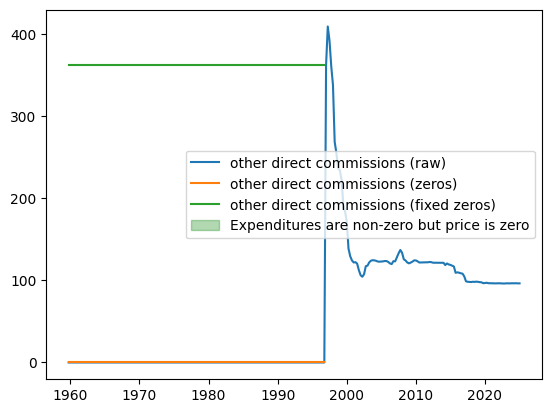

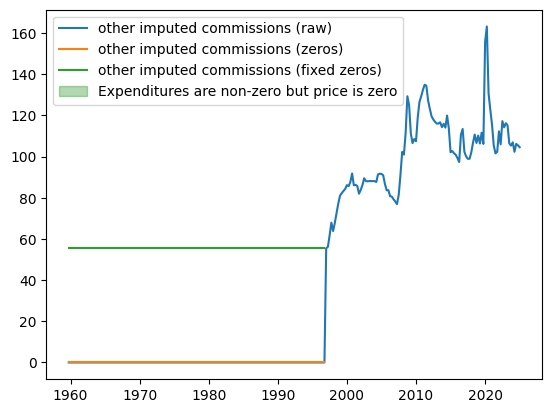

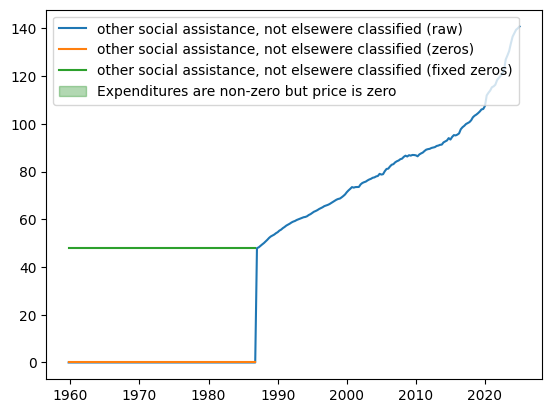

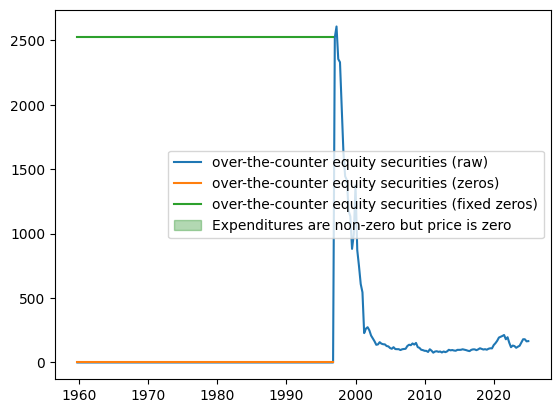

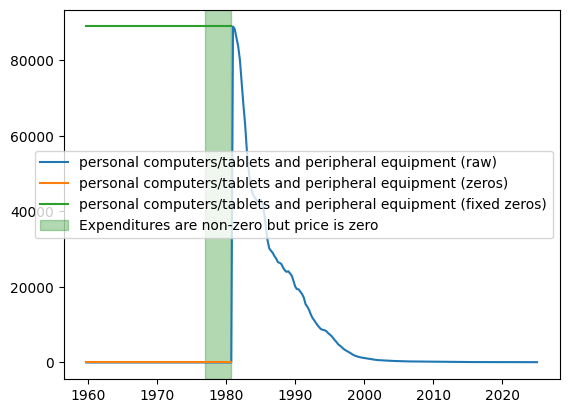

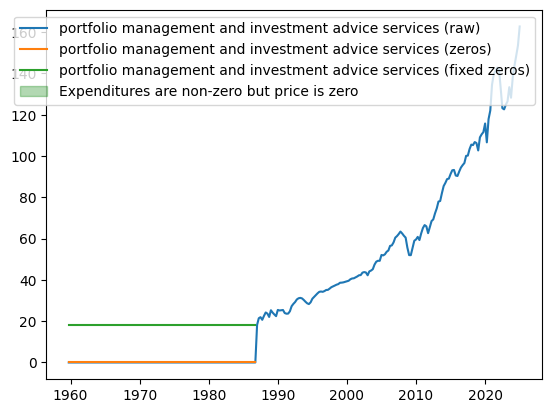

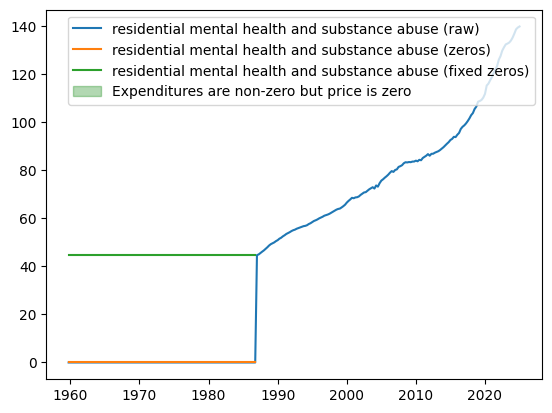

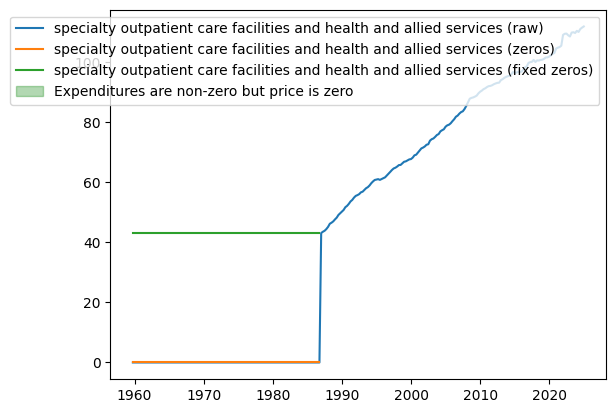

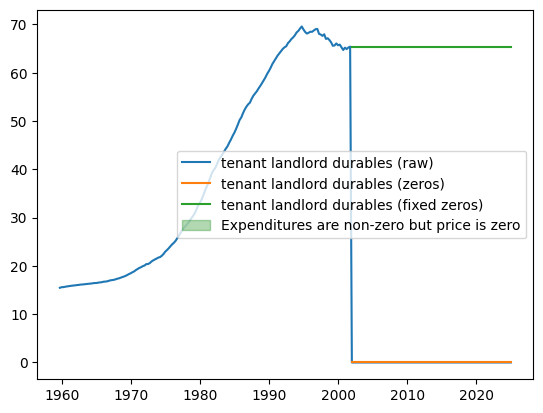

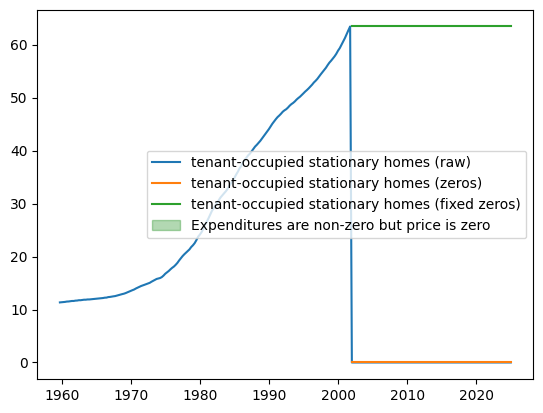

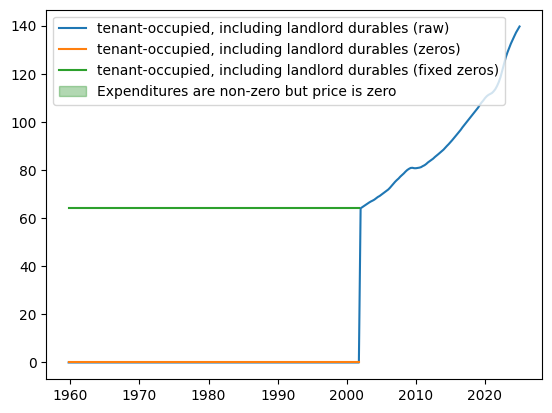

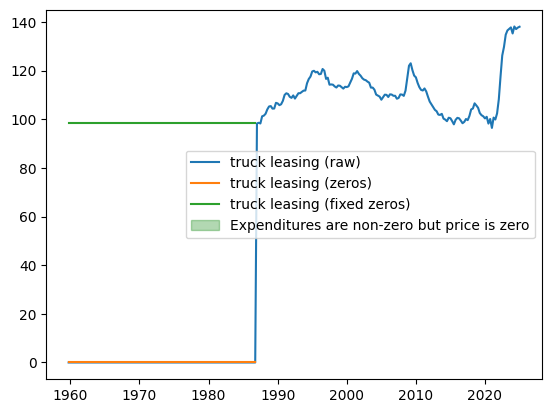

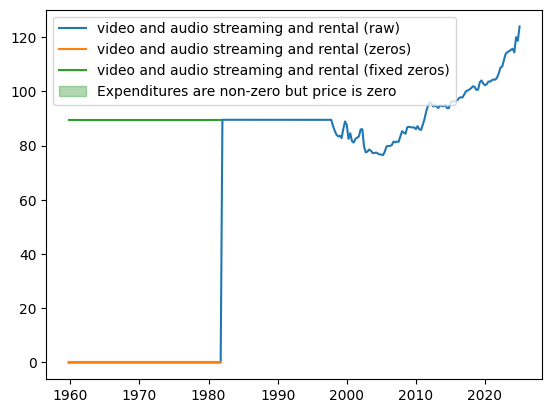

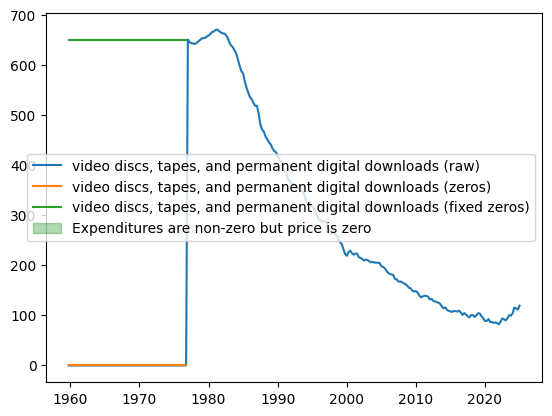

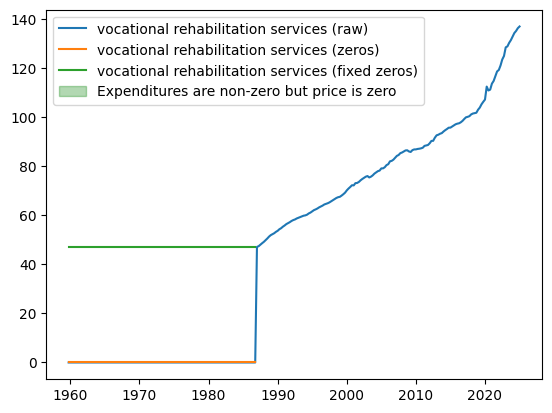

In [ ]:
# Cleaning added by NS 5/14/26
# Idea is that we shouldn't make prices 0. What we want to do is make the price constant at the level last observed. If a 
# series is always 0, then it should be the case that expenditure is also 0. So we keep expenditure at 0 and set prices = 1.
# If a series is sometimes 0, we either use its future value or its past value. let me document this.
def fix_zeros_series(s):
    """
    Replace zeros (treated as missing) in a single time series (pd.Series):
      - Leading zeros  → first non-zero value (backfill)
      - Trailing zeros → last non-zero value (forward-fill)
      - Interior zeros → linear interpolation between neighbors
    
    An all-zero series stays all-NaN (nothing to anchor from).
    """
    s = s.replace(0, np.nan)
    s = s.interpolate(method="linear")  # interior gaps only
    s = s.bfill()                        # leading NaN
    s = s.ffill()                        # trailing NaN
    return s


def fix_zeros_wide(df):
    """
    Apply fix_zeros_series row-wise to a wide DataFrame
    (rows = products, columns = dates).
    Returns a new DataFrame; original is unchanged.
    """
    return df.apply(fix_zeros_series, axis=1)


for ind in P.index:
    zero_ind = P.loc[ind,:] == 0.0
    omega_zero_ind = bea_expenditures_weights.loc[ind,:] == 0.0
    omega_non_zero_P_zero_ind = (~omega_zero_ind) & (zero_ind)

    if np.any(omega_zero_ind[zero_ind] == False):
        print(ind)
    
    if np.sum(zero_ind) > 0:
        fig, ax = plt.subplots()
        # Plot the series
        ax.plot(P.columns, P.loc[ind,:], label=ind+ ' (raw)')
        #plt.ylim(-10, 1000)
        ax.plot(P.columns[zero_ind], P.loc[ind,zero_ind], label=ind + ' (zeros)')
        fixed = fix_zeros_series(P.loc[ind,:])
        ax.plot(P.columns[zero_ind],fixed[zero_ind], label=ind + ' (fixed zeros)')
        if sum(omega_non_zero_P_zero_ind)  >0 :
            ax.fill_between(P.columns, 0, 1, where=omega_non_zero_P_zero_ind, 
                color='green', alpha=0.3, 
                transform=ax.get_xaxis_transform(), label = 'Expenditures are non-zero but price is zero')
        ax.legend()
    
        





# Delta Monthly

In [33]:
delta_final_monthly = {}

for date, zero_products in all_bad_products_dict.items():
    current_delta = delta_final.copy()
    zero_products = current_delta.index.intersection(zero_products)

    current_delta.loc[zero_products, :] = 0
    current_delta.loc[:, zero_products] = 0

    delta_final_monthly[date] = current_delta

# Gamma Monthly

In [34]:
gamma_monthly = {}

for date, current_delta in delta_final_monthly.items():
    row_sums = current_delta.sum(axis=1)
    
    gamma = pd.DataFrame(row_sums, columns=["Row_Sum"])
    gamma.index = current_delta.index
    gamma = gamma.apply(pd.to_numeric, errors="coerce")
    
    gamma_monthly[date] = gamma

# Omega Monthly

In [35]:
omega_monthly = {}

for date, current_delta in delta_final_monthly.items():
    gamma = gamma_monthly[date]

    delta_gamma = current_delta.merge(
        gamma,
        left_on=gamma.index,
        right_on=current_delta.index
    )

    delta_gamma = delta_gamma.set_index(delta_gamma.columns[0])

    row_sums = delta_gamma.iloc[:, -1].copy()
    row_sums[row_sums == 0] = np.nan

    omega = delta_gamma.iloc[:, :-1].div(row_sums, axis=0)

    omega.columns.name = None
    omega.index.name = None
    omega = omega.apply(pd.to_numeric, errors="coerce")
    omega = omega.fillna(0)

    omega_monthly[date] = omega

# A Matrix Monthly

In [36]:
A_monthly = {}

for date in delta_final_monthly:
    gamma = gamma_monthly[date]["Row_Sum"].reindex(omega_monthly[date].index)
    omega = omega_monthly[date]

    A = omega.mul(gamma, axis=0)

    A_monthly[date] = A.T

# Omega_VA_T

In [37]:
omega_PCE_monthly = bea_expenditures_weights.copy()

omega_VA_T_monthly = {}

for date in A_monthly:
    A = A_monthly[date].astype(float)

    omega_pce = bea_expenditures_weights[date].reindex(A.index).fillna(0).astype(float)

    I = np.eye(A.shape[0])

    va_share = 1 - A.sum(axis=1)

    diag_va_share = pd.DataFrame(
        np.diag(va_share.to_numpy(dtype=float)),
        index=A.index,
        columns=A.index
    )

    leontief_inverse = pd.DataFrame(
        np.linalg.inv(I - A.to_numpy(dtype=float)),
        index=A.index,
        columns=A.columns
    )

    omega_VA_T = (
        omega_pce.to_frame().T
        @ leontief_inverse
        @ diag_va_share
    )

    omega_VA_T.index = [date]

    omega_VA_T_monthly[date] = omega_VA_T

# omega_VA as N x T
Omega_VA = pd.concat(
    {
        date: omega_VA_T.iloc[0]
        for date, omega_VA_T in omega_VA_T_monthly.items()
    },
    axis=1
)

Omega_VA.columns = pd.to_datetime(Omega_VA.columns)
Omega_VA = Omega_VA.sort_index(axis=1)

# P_VA

In [100]:
P_wide = bea_prices.pivot(index="products", columns="date", values="Prices")
P_wide.index = P_wide.index.astype(str).str.strip().str.lower()
P_wide.columns = pd.to_datetime(P_wide.columns)
P_wide = P_wide.sort_index(axis=1)
P_wide = P_wide.apply(pd.to_numeric, errors="coerce")

P_VA_monthly = {}
P_CPI = {}
P_CPI_VA_check = {}

for date, A in A_monthly.items():
    A = A.astype(float)

    P_t = P_wide[date].reindex(A.index).astype(float)

    omega_pce = bea_expenditures_weights[date].reindex(A.index).fillna(0).astype(float)
    P_CPI[date] = omega_pce.T @ P_t

    va_share = 1 - A.sum(axis=1)
    va_share = va_share.replace(0, np.nan)

    I_minus_A = pd.DataFrame(
        np.eye(A.shape[0]) - A.to_numpy(dtype=float),
        index=A.index,
        columns=A.columns
    )

    # Add the diag term in front from equation 1
    P_VA_t = (I_minus_A @ P_t).div(va_share)
    P_CPI_VA_check[date] = omega_VA_T_monthly[date].values @ P_VA_t

    P_VA_monthly[date] = P_VA_t.to_frame("P_VA")

P_VA = pd.concat(
    {date: x["P_VA"] for date, x in P_VA_monthly.items()},
    axis=1
)

P_VA.columns = pd.to_datetime(P_VA.columns)
P_VA = P_VA.sort_index(axis=1)


# Check CPI and VA version are the same
P_CPI = pd.DataFrame(index = P_CPI.keys(), data = P_CPI.values(), columns=["P_CPI"])
P_CPI_to_check = pd.DataFrame(index = P_CPI_VA_check.keys(), data = P_CPI_VA_check.values(), columns=["P_CPI"])

if max(abs(P_CPI['P_CPI'] - P_CPI_to_check['P_CPI']))>10**(-6):
    print("CPI check failed")
else:
    print("CPI check passed")



CPI check passed


# Omega_Pi_VA and Pi_VA

In [ ]:
P_VA_lag = P_VA.shift(1, axis=1)
Omega_VA_lag = Omega_VA.shift(1, axis=1)

# pi_VA,p,t = P_VA,p,t / P_VA,p,t-1
pi_VA_p_t = P_VA.div(P_VA_lag).replace([np.inf, -np.inf], np.nan)

# omega_piVA,p,t =
# omega_VA,p,t * P_VA,p,t-1
# -----------------------------------------------
# sum_p' omega_VA,p',t-1 * P_VA,p',t-1
numerator = Omega_VA * P_VA_lag

# denominator uses lagged omega_VA and lagged P_VA, exactly as in the note
denominator = (Omega_VA_lag * P_VA_lag).sum(axis=0, min_count=1)

omega_pi_va_p_t = numerator.div(denominator, axis=1)
omega_pi_va_p_t

CPI_inflation_test = np.sum(omega_pi_va_p_t * pi_VA_p_t,axis=0)
CPI_inflation_test_again = np.sum(Omega_VA *P_VA,axis=0).div(np.sum(Omega_VA_lag *P_VA_lag,axis=0))

CPI_inflation = P_CPI['P_CPI'] / P_CPI['P_CPI'].shift(1)

# ___________________________________________________________________
# Test
# ___________________________________________________________________
# Numerically stable version of omega_pi_va_p_t * pi_VA_p_t.
# This is algebraically identical where P_VA,p,t-1 is positive, and avoids 0 * inf
# when a product has P_VA,p,t-1 = 0.
va_gross_inflation_contribution_p_t = (Omega_VA * P_VA).div(denominator, axis=1)
omega_pi_va_times_pi_va_p_t = omega_pi_va_p_t.mul(pi_VA_p_t).mask(
    P_VA_lag.eq(0),
    va_gross_inflation_contribution_p_t,
)

# Product-level net-inflation contribution. This subtracts the lagged VA level share,
# so summing across products gives gross headline inflation minus 1.
va_lagged_level_share_p_t = (Omega_VA_lag * P_VA_lag).div(denominator, axis=1)
va_net_inflation_contribution_p_t = va_gross_inflation_contribution_p_t - va_lagged_level_share_p_t


# Nick's testing
CPI_df = pd.DataFrame(data = CPI_inflation)
CPI_df['CPI_inflation_test'] = CPI_inflation_test.T
CPI_df['CPI_inflation_test_again'] = CPI_inflation_test_again.T
CPI_df['CPI_diff'] = CPI_df['P_CPI'] - CPI_df['CPI_inflation_test']
CPI_df['CPI_diff_again'] = CPI_df['P_CPI'] - CPI_df['CPI_inflation_test_again']

time_to_check = CPI_df.loc[np.abs(CPI_df['CPI_diff'])>10**-6].index[2]
CPI_df.loc[np.abs(CPI_df['CPI_diff'])>10**-6]



index_to_worry = (Omega_VA!=0)* (P_VA_lag==0) * (P_VA!=0)

for col in index_to_worry.columns:
    if index_to_worry[col].any():
        omega_pi_va_p_t.loc[index_to_worry[col],col] = Omega_VA.loc[index_to_worry[col],col]  / denominator[col]
        pi_VA_p_t.loc[index_to_worry[col],col] = P_VA.loc[index_to_worry[col],col] 
    

va_net_inflation_contribution_p_t = omega_pi_va_p_t.mul(pi_VA_p_t) - va_lagged_level_share_p_t

CPI_inflation_test = np.sum(omega_pi_va_p_t * pi_VA_p_t,axis=0)
CPI_df['Final_CPI'] = CPI_inflation_test
CPI_df['Final_Diff'] = CPI_df['P_CPI'] - CPI_df['Final_CPI']



/var/folders/hx/h9ft_v812fs68lgk203tqsq80000gn/T/ipykernel_11681/893316173.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  P_VA_lag = P_VA.shift(1, axis=1)
/var/folders/hx/h9ft_v812fs68lgk203tqsq80000gn/T/ipykernel_11681/893316173.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Omega_VA_lag = Omega_VA.shift(1, axis=1)


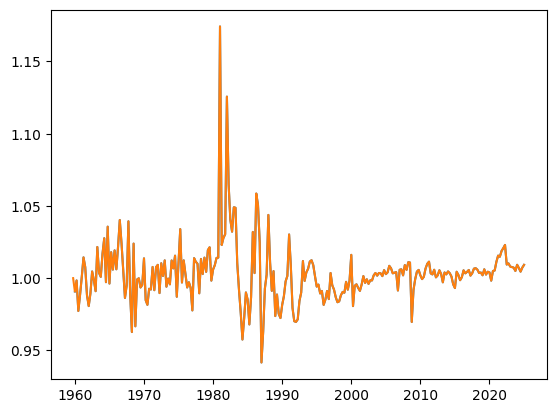

In [421]:
plt.plot(CPI_df.index, CPI_df['P_CPI'], label='CPI')
plt.plot(CPI_df.index, va_net_inflation_contribution_p_t.sum()+1, label='CPI')


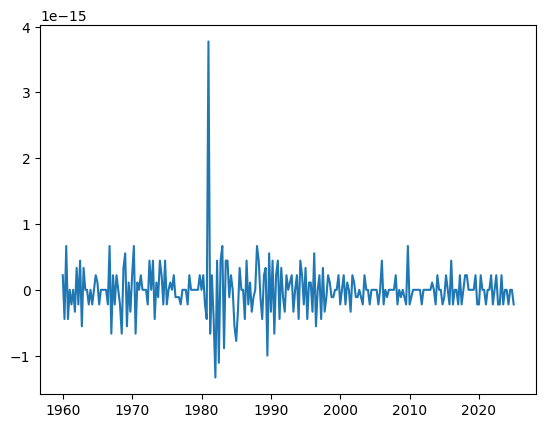

In [428]:
plt.plot(CPI_df.index, CPI_df['P_CPI'] - (va_net_inflation_contribution_p_t.sum()+1), label='CPI')

In [342]:
# Use the combined quarterly BEA + PEQ prices
prices_wide = bea_prices.pivot(index='products', columns='date', values='Prices')
prices_wide = prices_wide.sort_index(axis=1)

# Keep only products used in the classification
prices_wide = prices_wide.loc[prices_wide.index.intersection(pi_VA_p_t.index)]
prices_wide = prices_wide[~prices_wide.index.duplicated(keep='first')]

# Quarter-over-quarter inflation
inflation_gross = prices_wide / prices_wide.shift(1, axis=1)

# Expenditure weights from combined quarterly BEA + PEQ expenditures
bea_expenditures_wide = bea_expenditures.pivot(index='products', columns='date', values='Expenditures')
bea_expenditures_wide = bea_expenditures_wide.sort_index(axis=1)
bea_expenditures_wide = bea_expenditures_wide.loc[bea_expenditures_wide.index.intersection(pi_VA_p_t.index)]
bea_expenditures_wide = bea_expenditures_wide[~bea_expenditures_wide.index.duplicated(keep='first')]

# to_zero = peq_only["PCE Bridge Products"].astype(str).str.strip().str.lower().drop_duplicates()

to_zero = pd.concat(
    [
        peq_only["PCE Bridge Products"],
        # fake_fill_only["PCE Bridge Products"],
    ],
    ignore_index=True
).astype(str).str.strip().str.lower().drop_duplicates()


date_cols = [c for c in bea_expenditures_wide.columns if c != "products"]

bea_expenditures_wide.loc[
    bea_expenditures_wide.index.isin(to_zero),
    date_cols
] = 0

expenditure_weights = bea_expenditures_wide.div(bea_expenditures_wide.sum(axis=0), axis=1)
expenditure_weights

date,1959-10-01,1960-01-01,1960-04-01,1960-07-01,1960-10-01,1961-01-01,1961-04-01,1961-07-01,1961-10-01,1962-01-01,...,2022-10-01,2023-01-01,2023-04-01,2023-07-01,2023-10-01,2024-01-01,2024-04-01,2024-07-01,2024-10-01,2025-01-01
accessories and parts,0.002865,0.002903,0.002941,0.002906,0.002907,0.002876,0.002893,0.003023,0.003040,0.003093,...,0.003627,0.003653,0.003708,0.003719,0.003679,0.003635,0.003613,0.003594,0.003629,0.003606
air transportation,0.002077,0.002053,0.002068,0.002220,0.002256,0.002196,0.002348,0.002375,0.002460,0.002589,...,0.008836,0.008593,0.008929,0.008969,0.008873,0.009230,0.009459,0.009369,0.009482,0.009342
alcohol in purchased meals,0.014362,0.013773,0.013855,0.013520,0.013581,0.013537,0.013330,0.013192,0.013169,0.013134,...,0.007911,0.008079,0.008038,0.008110,0.008171,0.008099,0.008034,0.008032,0.008049,0.008040
all other professional medical services,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.004737,0.004768,0.004787,0.004819,0.004895,0.004984,0.004942,0.005059,0.005072,0.005083
"amusement parks, campgrounds, and related recreational services",0.002784,0.002820,0.002808,0.002836,0.002844,0.002933,0.003010,0.003105,0.003155,0.003178,...,0.004812,0.004719,0.004606,0.004512,0.004670,0.004631,0.004369,0.004230,0.004092,0.004118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
water transportation,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,0.000310,0.000325,0.000326,0.000321,0.000336,0.000322,0.000340,0.000351,0.000344,0.000356
window coverings,0.002706,0.002626,0.002615,0.002567,0.002561,0.002577,0.002546,0.002535,0.002520,0.002518,...,0.001712,0.001715,0.001706,0.001693,0.001655,0.001623,0.001613,0.001610,0.001607,0.001584
wine,0.001791,0.001751,0.001739,0.001764,0.001785,0.001819,0.001818,0.001823,0.001867,0.001949,...,0.003694,0.003671,0.003637,0.003604,0.003595,0.003565,0.003554,0.003540,0.003521,0.003492
women's and girls' clothing,0.040950,0.040635,0.040601,0.040184,0.039996,0.040456,0.039974,0.040201,0.040546,0.039963,...,0.012214,0.012226,0.012079,0.012222,0.012120,0.011907,0.012021,0.011915,0.011946,0.012017


# Find Sales

In [343]:
# calculate sales in product and time period
sales = pd.DataFrame({'date': pd.Series(dtype='datetime64[ns]'),
                   'products': pd.Series(dtype='str'),
                   'sales': pd.Series(dtype='float')})

for date in dates:

    gamma = gamma_monthly.get(date)
    omega = omega_monthly.get(date)
 
    # filter expenditures for the current date
    expenditures_date = bea_expenditures[bea_expenditures['date'] == date][['products', 'Expenditures']].set_index('products')
    expenditures_date = expenditures_date.sort_index()
    expenditures_date = expenditures_date.apply(pd.to_numeric, errors='coerce')

    gamma_series = gamma["Row_Sum"]
    diag_matrix = np.diag(gamma_series)

    x = np.identity(len(omega)) - (omega.T @ diag_matrix)

    sales_date = np.linalg.inv(x) @ expenditures_date

    sales_date['date'] = date
    sales_date['products'] = expenditures_date.index
    sales_date.rename(columns={'Expenditures': 'sales'}, inplace=True)

    sales = pd.concat([sales, sales_date], ignore_index=True)

# Find Prices of Intermediates

In [344]:
# Leontief P_VA is computed directly above, so the old Cobb-Douglas
# intermediate-price object is no longer needed. Keep an empty placeholder
# so older exploratory cells that reference `intermediates` do not fail.
intermediates = pd.DataFrame(
    columns=["date", "products", "intermediates"]
)

# Find Price of Value Added

In [345]:
# Use the Leontief value-added price matrix constructed above.
value_added = P_VA.copy()
value_added.index.name = "products"
value_added = value_added.reset_index().melt(
    id_vars="products",
    var_name="date",
    value_name="value_added",
)
value_added["products"] = value_added["products"].astype(str).str.strip().str.lower()
value_added["date"] = pd.to_datetime(value_added["date"])
value_added["value_added"] = pd.to_numeric(value_added["value_added"], errors="coerce")

# Sales and Value Added VAR

In [346]:
lags = 4
residuals_part = []

for product in P_VA.index:

    product_bad_dates = products_with_zero_somwhere[products_with_zero_somwhere["products"] == product]
    calculated = pd.merge(left=value_added, right=sales, on=['products', 'date'], how='inner')
    calculated = calculated[calculated['products'] == product][['date', 'value_added', 'sales']].sort_values(['date'])
    calculated = calculated.set_index('date')

    if not product_bad_dates.empty: 
        calculated = calculated[~calculated.index.isin(product_bad_dates['date'])] # remove rows before we have all time series data
    
    calculated['value_added'] = np.log(calculated['value_added']).diff()
    calculated['sales'] = np.log(calculated['sales']).diff()

    calculated.replace([np.inf, -np.inf, np.nan], 0, inplace=True)
    
    full_index_calc = pd.date_range(start=calculated.index.min(), end=calculated.index.max(), freq='QS')
    calculated = calculated.reindex(full_index_calc)

    model_calculated = VAR(calculated)
    result_calculated = model_calculated.fit(lags)

    residuals_calculated = result_calculated.resid.reset_index()
    residuals_calculated['products'] = product
    
    residuals_part.append(residuals_calculated)
    

IO_residuals = pd.concat(residuals_part, ignore_index=True)
IO_residuals.rename(columns={'index': 'date', 'value_added': 'residual_value_added', 'sales': 'residual_sales'}, inplace=True)
IO_residuals = IO_residuals.groupby(['date', 'products']).sum(min_count=1).reset_index()
IO_residuals = IO_residuals.sort_values(['date', 'products'])

/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testing/S

# Price and Quantity VAR

In [347]:
lags = 4
residual_temp = []

for product in P_VA.index:

    original = bea_PQE_merged[bea_PQE_merged['products'] == product][['date', 'Prices', 'Quantities']].sort_values(['date'])
    original = original.set_index('date')

    original.dropna(inplace=True)

    original['Prices'] = np.log(original['Prices']).diff()
    original['Quantities'] = np.log(original['Quantities']).diff()
     

    original.replace([np.inf, -np.inf], np.nan, inplace=True)
    original.dropna(inplace=True)

    full_index = pd.date_range(start=original.index.min(), end=original.index.max(), freq='QS')
    original = original.reindex(full_index)

    model_original = VAR(original)
    result_original = model_original.fit(lags)

    residuals_original = result_original.resid.reset_index()
    residuals_original['products'] = product
    
    residual_temp.append(residuals_original)
    
residuals_normal = pd.concat(residual_temp, ignore_index=True)
residuals_normal.rename(columns={'index': 'date', 'Prices': 'residual_prices', 'Quantities': 'residual_quantities'}, inplace=True)
residuals_normal = residuals_normal.groupby(['date', 'products']).sum(min_count=1).reset_index()
residuals_normal = residuals_normal.sort_values(['date', 'products'])

/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Nick/Desktop/github testi

# Classification of Price of Value Added and Real Production

In [348]:
residuals_normal['majority_demand'] = ((residuals_normal['residual_prices'] * residuals_normal['residual_quantities']) >= 0).astype(int)
residuals_normal['majority_supply'] = ((residuals_normal['residual_prices'] * residuals_normal['residual_quantities']) < 0).astype(int)

IO_residuals['majority_demand_a'] = ((IO_residuals['residual_value_added'] * IO_residuals['residual_sales']) >= 0).astype(int)
IO_residuals['majority_supply_a'] = ((IO_residuals['residual_value_added'] * IO_residuals['residual_sales']) < 0).astype(int)

In [349]:
def plot_graphs(data, plot_title, plot_text):
    """Function to Graph Stacked Plot"""
    data = data.loc[data.index >= pd.Timestamp('1970-01-01')]

    supply_inflation = data[["annual_supply_inflation"]].copy()
    supply_inflation.rename(columns={'annual_supply_inflation': 'Supply Inflation'}, inplace=True)

    demand_inflation = data[["annual_demand_inflation"]].copy()
    demand_inflation.rename(columns={'annual_demand_inflation': 'Demand Inflation'}, inplace=True)

    supply_inflation['supply_pos'] = supply_inflation['Supply Inflation'].apply(lambda x: x if x > 0 else 0)
    demand_inflation['demand_pos'] = demand_inflation['Demand Inflation'].apply(lambda x: x if x > 0 else 0)
    supply_inflation['supply_neg'] = supply_inflation['Supply Inflation'].apply(lambda x: x if x < 0 else 0)
    demand_inflation['demand_neg'] = demand_inflation['Demand Inflation'].apply(lambda x: x if x < 0 else 0)

    demand_inflation = demand_inflation.iloc[:-1]
    supply_inflation = supply_inflation.iloc[:-1]

    plt.figure(figsize=(26, 12))

    plt.stackplot(supply_inflation.index, demand_inflation['demand_pos'], supply_inflation['supply_pos'], colors= ["#008000", "#FF0000"], labels = ["Demand", "Supply"])
    plt.stackplot(supply_inflation.index, demand_inflation['demand_neg'], supply_inflation['supply_neg'], colors= ["#008000", "#FF0000"])
    if "annual_total_inflation" in data.columns:
        split_total = (
            data.loc[supply_inflation.index, "annual_demand_inflation"]
            + data.loc[supply_inflation.index, "annual_supply_inflation"]
        )
        plt.plot(split_total.index, split_total, color="0.35", linestyle="--", linewidth=1.5, label="Demand + Supply")
        total = data.loc[supply_inflation.index, "annual_total_inflation"]
        plt.plot(total.index, total, color="black", linewidth=2, label="CPI")
    plt.xlabel('Date')
    plt.ylabel('Inflation')
    plt.title(f'{plot_title}')
    plt.legend()

    plt.text(0.02, 0.95, 
         f'{plot_text}', 
         transform=plt.gca().transAxes, fontsize=9,
         bbox=dict(facecolor='white', alpha=0.8))

    return plt

In [350]:
# IO VAR classifictions
D_IO = IO_residuals.pivot(index='products', columns='date', values='majority_demand_a')

# Shapiro VAR classifictions
D_shapiro = residuals_normal.pivot(index='products', columns='date', values='majority_demand')

In [420]:
dates = sorted(
    set(D_IO.columns)
    & set(D_shapiro.columns)
    & set(pi_VA_p_t.columns)
    & set(omega_pi_va_p_t.columns)
)
dates = [d for d in dates if d.year >= 1985 and d.year < 2025]

TypeError: 'DatetimeIndex' object is not callable

In [352]:
# Use the combined quarterly BEA + PEQ prices
prices_wide = bea_prices.pivot(index='products', columns='date', values='Prices')
prices_wide = prices_wide.sort_index(axis=1)

# Keep only products used in the classification
prices_wide = prices_wide.loc[prices_wide.index.intersection(D_shapiro.index)]
prices_wide = prices_wide[~prices_wide.index.duplicated(keep='first')]

# Quarter-over-quarter inflation
inflation = (
    prices_wide.pct_change(axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)


# Expenditure weights from combined quarterly BEA + PEQ expenditures
bea_expenditures_wide = bea_expenditures.pivot(index='products', columns='date', values='Expenditures')
bea_expenditures_wide = bea_expenditures_wide.sort_index(axis=1)
bea_expenditures_wide = bea_expenditures_wide.loc[bea_expenditures_wide.index.intersection(D_shapiro.index)]
bea_expenditures_wide = bea_expenditures_wide[~bea_expenditures_wide.index.duplicated(keep='first')]

# to_zero = peq_only["PCE Bridge Products"].astype(str).str.strip().str.lower().drop_duplicates()

to_zero = pd.concat(
    [
        peq_only["PCE Bridge Products"],
        # fake_fill_only["PCE Bridge Products"],
    ],
    ignore_index=True
).astype(str).str.strip().str.lower().drop_duplicates()


date_cols = [c for c in bea_expenditures_wide.columns if c != "products"]

bea_expenditures_wide.loc[
    bea_expenditures_wide.index.isin(to_zero),
    date_cols
] = 0

expenditure_weights = bea_expenditures_wide.div(bea_expenditures_wide.sum(axis=0), axis=1)
expenditure_weights

date,1959-10-01,1960-01-01,1960-04-01,1960-07-01,1960-10-01,1961-01-01,1961-04-01,1961-07-01,1961-10-01,1962-01-01,...,2022-10-01,2023-01-01,2023-04-01,2023-07-01,2023-10-01,2024-01-01,2024-04-01,2024-07-01,2024-10-01,2025-01-01
products,,,,,,,,,,,,,,,,,,,,,
accessories and parts,0.002865,0.002903,0.002941,0.002906,0.002907,0.002876,0.002893,0.003023,0.003040,0.003093,...,0.003627,0.003653,0.003708,0.003719,0.003679,0.003635,0.003613,0.003594,0.003629,0.003606
air transportation,0.002077,0.002053,0.002068,0.002220,0.002256,0.002196,0.002348,0.002375,0.002460,0.002589,...,0.008836,0.008593,0.008929,0.008969,0.008873,0.009230,0.009459,0.009369,0.009482,0.009342
alcohol in purchased meals,0.014362,0.013773,0.013855,0.013520,0.013581,0.013537,0.013330,0.013192,0.013169,0.013134,...,0.007911,0.008079,0.008038,0.008110,0.008171,0.008099,0.008034,0.008032,0.008049,0.008040
all other professional medical services,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.004737,0.004768,0.004787,0.004819,0.004895,0.004984,0.004942,0.005059,0.005072,0.005083
"amusement parks, campgrounds, and related recreational services",0.002784,0.002820,0.002808,0.002836,0.002844,0.002933,0.003010,0.003105,0.003155,0.003178,...,0.004812,0.004719,0.004606,0.004512,0.004670,0.004631,0.004369,0.004230,0.004092,0.004118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
water transportation,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,...,0.000310,0.000325,0.000326,0.000321,0.000336,0.000322,0.000340,0.000351,0.000344,0.000356
window coverings,0.002706,0.002626,0.002615,0.002567,0.002561,0.002577,0.002546,0.002535,0.002520,0.002518,...,0.001712,0.001715,0.001706,0.001693,0.001655,0.001623,0.001613,0.001610,0.001607,0.001584
wine,0.001791,0.001751,0.001739,0.001764,0.001785,0.001819,0.001818,0.001823,0.001867,0.001949,...,0.003694,0.003671,0.003637,0.003604,0.003595,0.003565,0.003554,0.003540,0.003521,0.003492


# Inflation Contribution based on Classification

In [413]:
inflation_parts_IO = {}

# IO loop using va_net_inflation_coantribution_p_t 
for date in D_IO:
    current_demand = D_IO[str(date)]
    current_supply = 1 - current_demand
    contrib = va_net_inflation_contribution_p_t[date]
    # contrib = va_net_clean[date]
    inflation_parts_IO[date] = [
        (current_demand * contrib).sum(),
        (current_supply * contrib).sum(),
    ]


# IO loop 
# for date in D_IO:
#     current_demand = D_IO[str(date)]
#     current_supply = 1 - current_demand

#     current_weights = omega_pi_va_p_t[date]
#     current_inflation = pi_VA_p_t[date]

#     demand_inflation = (current_demand * current_weights * current_inflation).sum()
#     supply_inflation = (current_supply * current_weights * current_inflation).sum()

#     inflation_parts_IO[date] = [demand_inflation, supply_inflation]



# Final demand and supply driven inflation
inflation_IO_final = pd.DataFrame(inflation_parts_IO, index=['demand_inflation', 'supply_inflation'])
inflation_IO_final = inflation_IO_final.T

# Shapiro Classification Aggregated Monthly Inflation
inflation_parts_shapiro = {}

for date in D_shapiro:
    current_demand = D_shapiro[str(date)]
    current_supply = 1 - current_demand

    current_weights = expenditure_weights[date]
    current_inflation = inflation[date]

    demand_inflation = (current_demand * current_weights * current_inflation).sum()
    supply_inflation = (current_supply * current_weights * current_inflation).sum()

    inflation_parts_shapiro[date] = [demand_inflation, supply_inflation]


inflation_shapiro_final = pd.DataFrame(inflation_parts_shapiro, index=['demand_inflation', 'supply_inflation'])
inflation_shapiro_final = inflation_shapiro_final.T

# Quarter to Annual Inflation

In [393]:
# IO Classification - Anual Supply Inflation
inflation_IO_final['annual_supply_inflation'] = (
    (inflation_IO_final['supply_inflation'].add(1).shift(1).rolling(window=4, min_periods=4).apply(np.prod, raw=True) - 1) * 100
)
# IO Classification - Anual Demand Inflation
inflation_IO_final['annual_demand_inflation'] = (
    (inflation_IO_final['demand_inflation'].add(1).shift(1).rolling(window=4, min_periods=4).apply(np.prod, raw=True) - 1) * 100
)
# Shapiro Classification - Anual Supply Inflation
inflation_shapiro_final['annual_supply_inflation'] = (
    (inflation_shapiro_final['supply_inflation'].add(1).shift(1).rolling(window=4, min_periods=4).apply(np.prod, raw=True) - 1) * 100
)
# Shapiro Classification - Anual Demand Inflation
inflation_shapiro_final['annual_demand_inflation'] = (
    (inflation_shapiro_final['demand_inflation'].add(1).shift(1).rolling(window=4, min_periods=4).apply(np.prod, raw=True) - 1) * 100
)

<module 'matplotlib.pyplot' from '/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

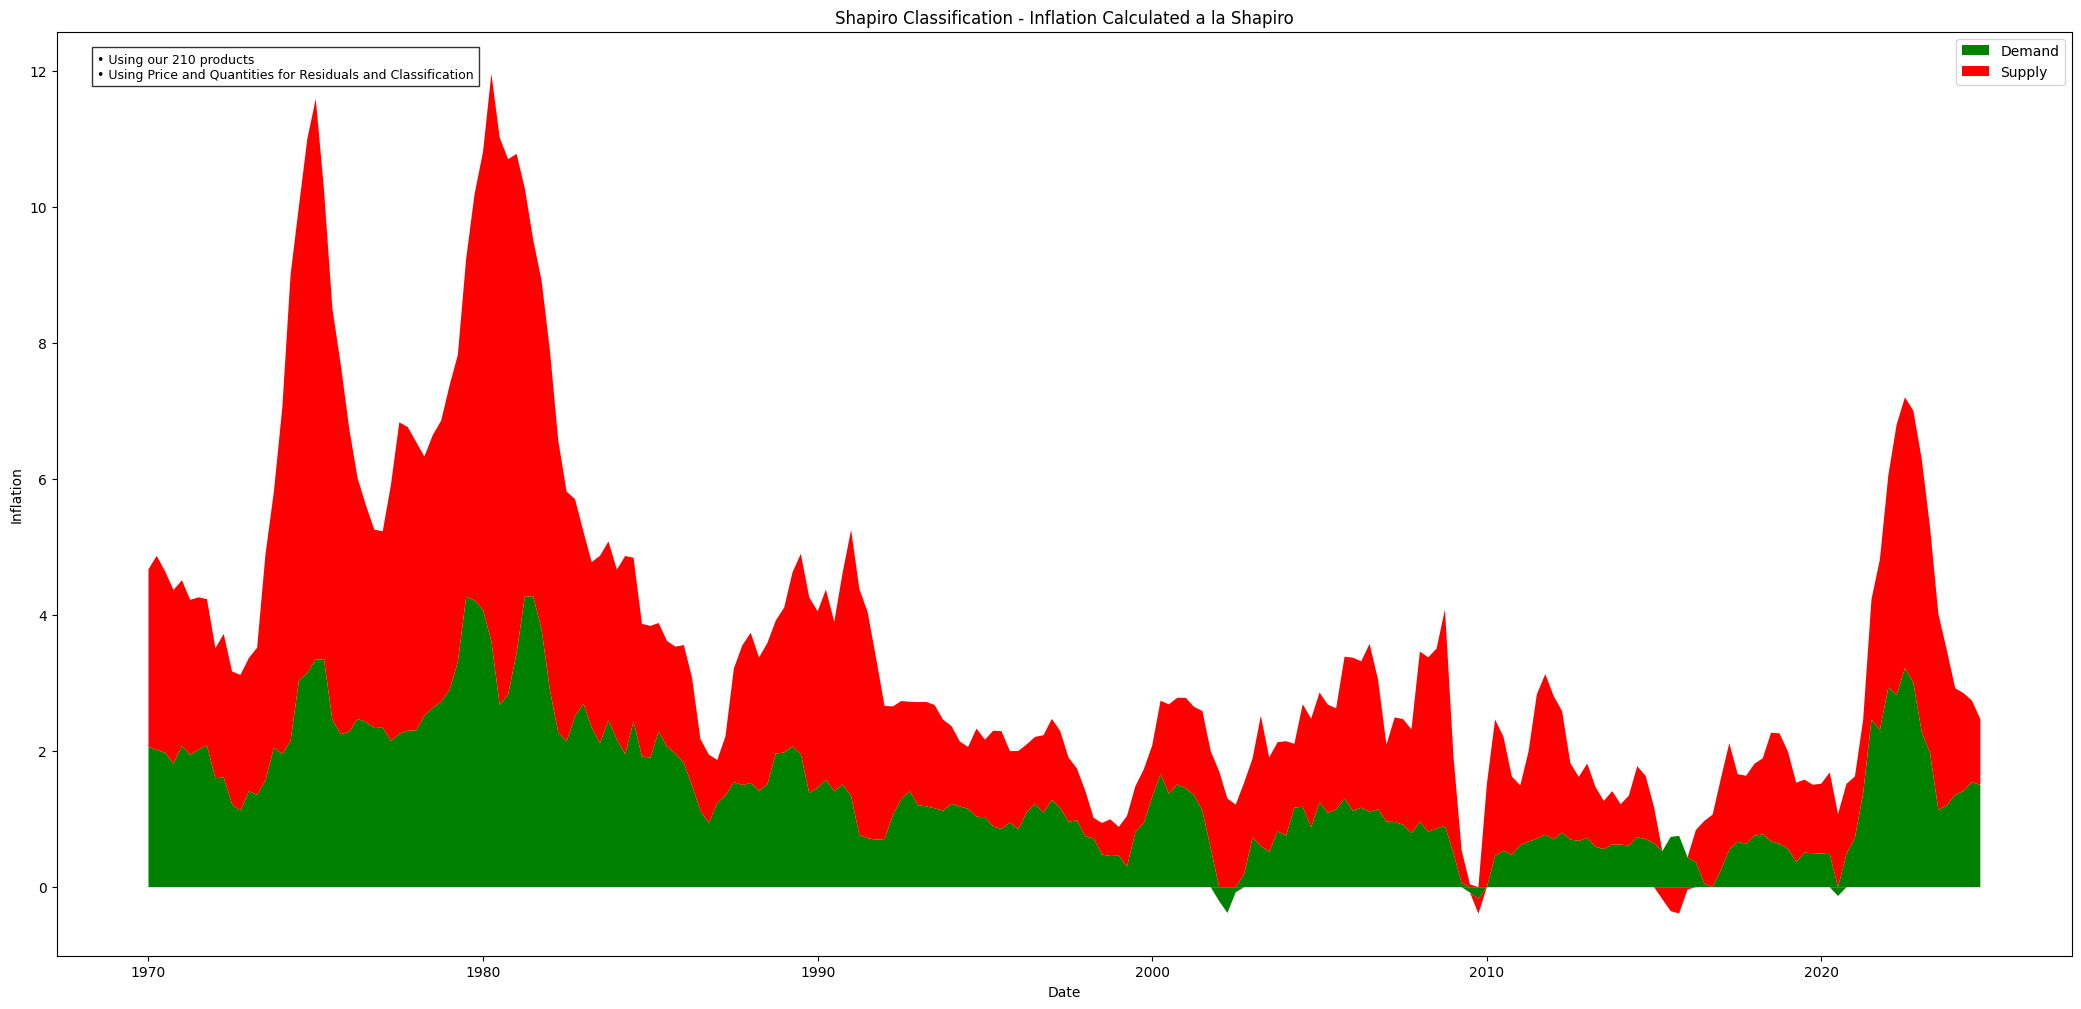

In [394]:
plot_graphs(inflation_shapiro_final, "Shapiro Classification - Inflation Calculated a la Shapiro", "• Using our 210 products \n• Using Price and Quantities for Residuals and Classification")

<module 'matplotlib.pyplot' from '/Users/Nick/Desktop/github testing/ShapirIO_new/shocks_productionnetworks/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

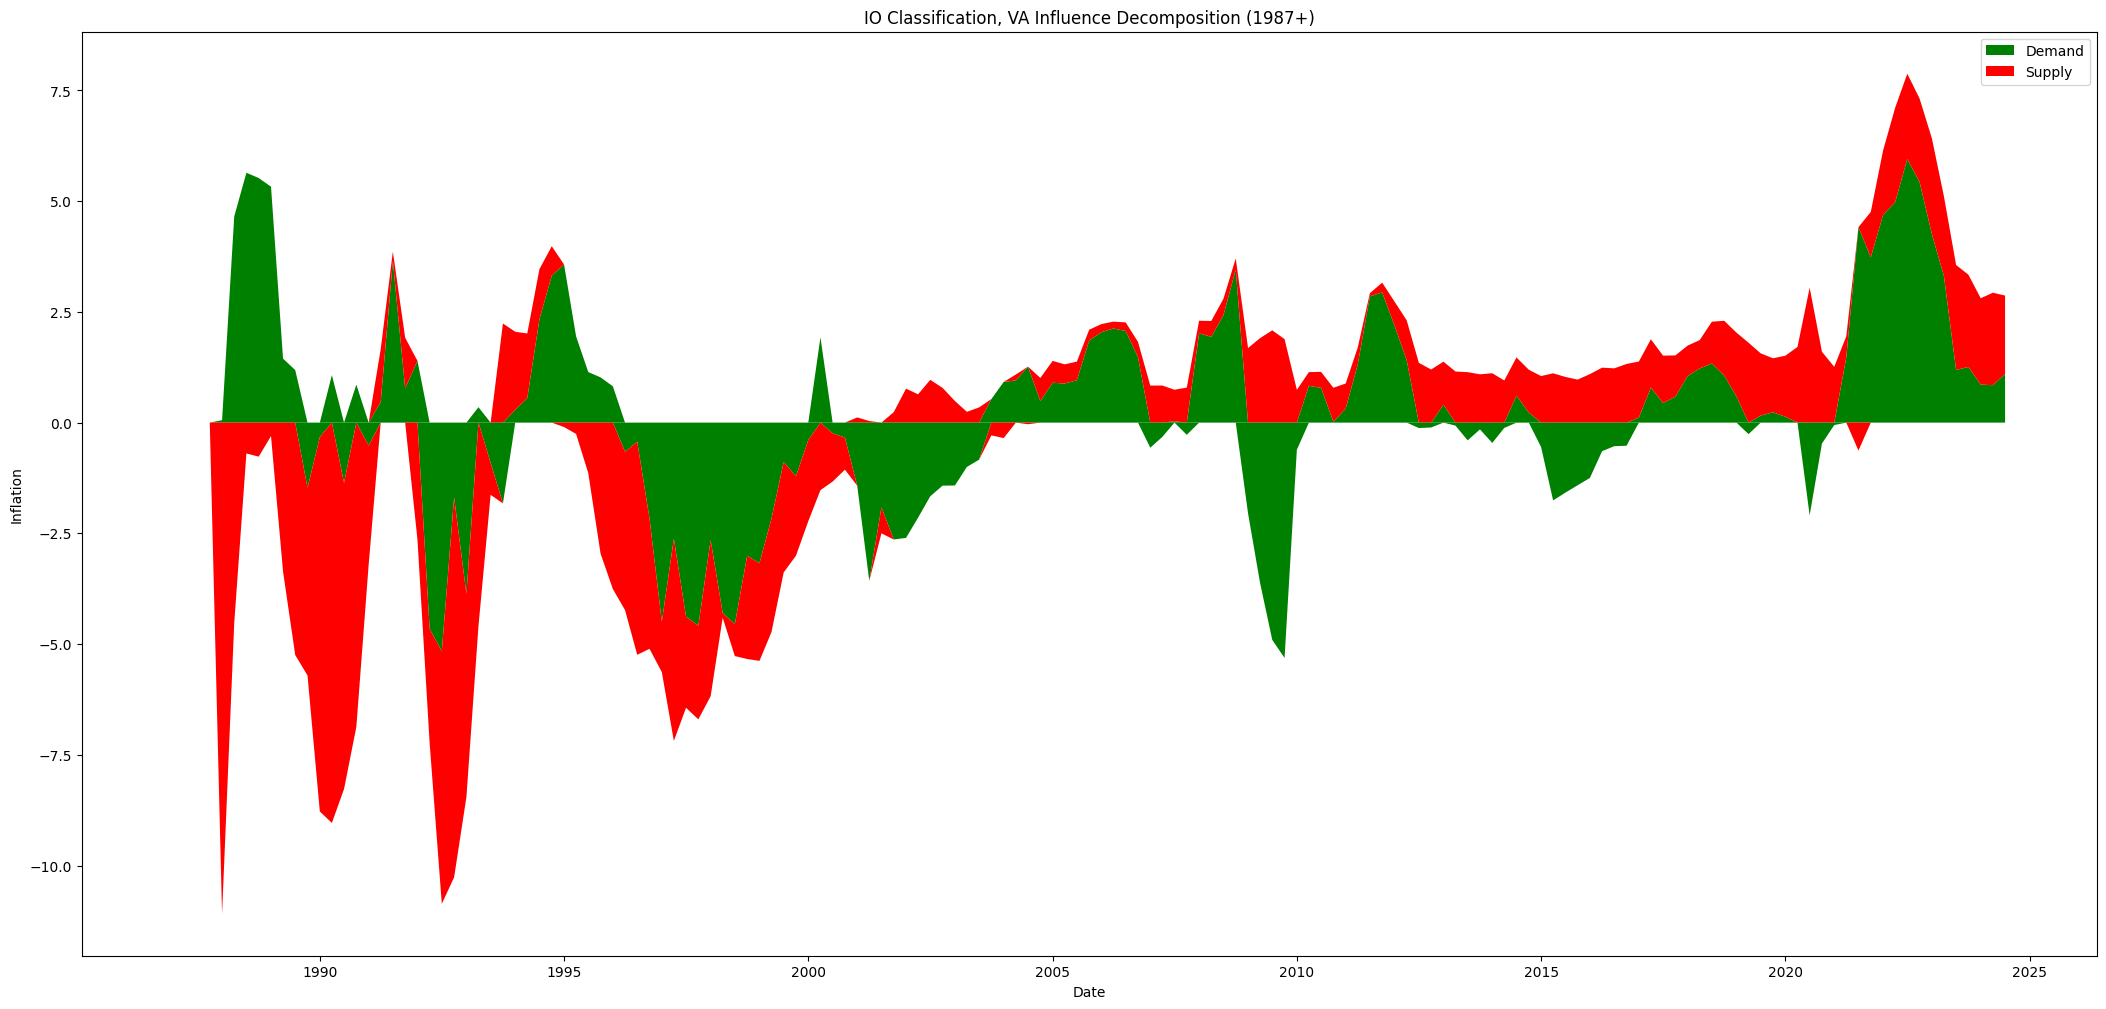

In [395]:
plot_graphs(inflation_IO_final, "IO Classification, VA Influence Decomposition (1987+)", "")